# 🍳 Recetario Inteligente — NLP Pipeline

> **Asignatura:** Procesamiento del Lenguaje Natural  
> **Descripción:** Sistema RAG multimodal para recomendación de recetas a partir de ingredientes disponibles, con soporte de entrada y salida por voz.

---

## Objetivo del proyecto

El objetivo principal es desarrollar una herramienta conversacional que dado un conjunto de ingredientes que el usuario tiene en casa, recupere y recomiende las recetas más similares de un corpus real.

La herramienta final (`app.py`) admite **dos modalidades de entrada**:
- **Texto:** el usuario escribe los ingredientes directamente.
- **Audio:** el usuario habla y el sistema transcribe, procesa y responde de forma también hablada simulando una conversación natural con un asistente de cocina.

> Como el fichero `app.py` no puede compartirse de forma autoejecutable porque requiere tener instaladas las dependencias locales (modelos descargados de text to speech y speech to text, Ollama corriendo, etc.) este notebook documenta tanto las pruebas hechas para elegir el modelo de embeddings como el ejemplo del proceso que se sigue en el archivo app.py para procesar las queries y el audio

---

**Fuente** | https://zenodo.org/records/3749328


---

## Estructura del notebook

El notebook está dividido en dos bloques principales:

### Parte 1 — Exploración y técnicas NLP (asignatura)

Aquí se analiza el dataset y se prueban los distintos enfoques de recuperación estudiados en la asignatura, comparando su idoneidad para este caso de uso concreto.

| Sección | Contenido |
|---|---|
| **0. Instalación** | Dependencias necesarias para ejecutar el notebook |
| **1. EDA** | Análisis exploratorio: distribución de categorías, dificultad, tiempo, ingredientes y valores nulos |
| **2. Feature Engineering** | Normalización de ingredientes, codificación de tiempo y dificultad, y preparación del dataset para su uso en el sistema de búsqueda |
| **3. Retrieval Léxico — BM25** | Búsqueda con `BM25Okapi`: queries con y sin filtros, análisis de limitaciones léxicas |
| **4. Retrieval Semántico — ChromaDB** | Embeddings con `Harrier`, `MiniLM`, `MPNet` y `E5`; comparativa de resultados por query |
| **5. Re-ranking** | Cross-encoders (`cross-encoder/ms-marco-MiniLM-L-6-v2`, `BAAI/bge-reranker-v2-m3`) y LLM como reranker (`codefuse-ai/F2LLM-v2-4B`); análisis de mejora sobre BM25 y E5|
| **6. Visualización UMAP** | Proyección 2D del espacio semántico para visualizar cómo se agrupan las recetas vectorizadas |

### Parte 2 — Componentes de la aplicación funcional

Ejemplificación de los módulos que se han integrado en `app.py`, mostrados aquí con ejemplos concretos ejecutables:

| Sección | Contenido |
|---|---|
| **7. Query Normalization** | Llamada al LLM vía Ollama (OpenAI SDK) para limpiar y normalizar la query del usuario antes del retrieval |
| **8. Pipeline de Audio** | Ejemplo completo con audio reproducible de entrada → transcripción con **Whisper** → normalización con LLM → retrieval semántico → respuesta en audio de salida con **Kokoro TTS** |




## 0. Instalación de dependencias


In [ ]:
#LIBRERÍAS
# !pip install rank-bm25 sentence-transformers chromadb transformers tqdm matplotlib seaborn plotly umap-learn openai accelerate bitsandbytes numpy pandas scikit-learn mxbai-rerank kokoro-onnx soundfile sounddevice openai-whisper

In [2]:
import csv, json, re, hashlib, random, warnings, os
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional
from collections import Counter, defaultdict
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import time
import umap
import textwrap
from tqdm import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification, BitsAndBytesConfig
import chromadb
from openai import OpenAI
import whisper
import sounddevice as sd
import soundfile as sf
import IPython.display as ipd
from kokoro_onnx import Kokoro


c:\Users\david\Desktop\david\portatil de david\2\entornomaster\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# INTALACIÓN DE KOKORO (MODELO TEXT TO SPEECH)


# url = "https://github.com/thewh1teagle/kokoro-onnx/releases/download/model-files-v1.0/kokoro-v1.0.onnx"
# urllib.request.urlretrieve(url, "kokoro-v1.0.onnx")

In [ ]:
# INSTALACIÓN DE VOCES PARA KOKORO


# url = "https://github.com/thewh1teagle/kokoro-onnx/releases/download/model-files-v1.0/voices-v1.0.bin"
# urllib.request.urlretrieve(url, "voices.bin")


In [ ]:
# PARA PODER EJECUTAR EL MODELO DE WHISPER DE TRANSCRIPCIÓN HACE FALTA TENER INSTALADA LA LIBRERIA openai-whisper y winget install ffmpeg

## 1. EDA — Análisis Exploratorio


### 1.1 Carga inicial del dataset


In [6]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CSV_PATH = r'C:\Users\david\Desktop\david\portatil de david\2\NLP\trabajogrupo\proyecto recetas\recetas.csv'  # ajusta la ruta si es necesario


In [7]:
df_raw = pd.read_csv(CSV_PATH, sep='|', on_bad_lines='skip', encoding='utf-8')
print(f'Shape: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (22374, 13)
Columnas: ['Id', 'Categoria', 'Nombre', 'Valoracion', 'Dificultad', 'Num_comensales', 'Tiempo', 'Tipo', 'Link_receta', 'Num_comentarios', 'Num_reviews', 'Fecha_modificacion', 'Ingredientes']


,Id,Categoria,Nombre,Valoracion,Dificultad,Num_comensales,Tiempo,Tipo,Link_receta,Num_comentarios,Num_reviews,Fecha_modificacion,Ingredientes
0,74138,Recetas de Aperitivos y tapas,Receta de Baleadas hondureñas,NaN,baja,2.0,10m,NaN,https://www.recetasgratis.net/receta-de-balead...,0,0,2020-04-06,"4 trotillas de harina,2 tazas de frijoles negr..."
1,74133,Recetas de Aperitivos y tapas,Receta de Tacos de carne molida,NaN,baja,4.0,30m,Plato principal,https://www.recetasgratis.net/receta-de-tacos-...,0,0,2020-03-27,"500 gramos de carne molida,1 papa mediana,2 cu..."
2,74154,Recetas de Aperitivos y tapas,Receta de Burritos norteños,NaN,muy baja,5.0,30m,Entrante,https://www.recetasgratis.net/receta-de-burrit...,0,0,2020-03-25,"10 tortillas de harina para burritos,500 gramo..."


In [13]:
# Resumen de valores nulos
null_pct = (df_raw.isna().sum() / len(df_raw) * 100).round(1)
print('Porcentaje de valores nulos por columna:')
print(null_pct[null_pct > 0].sort_values(ascending=False).to_string())


Porcentaje de valores nulos por columna:
Fecha_modificacion    49.5
Tipo                  48.8
Tiempo                42.3
Num_comensales        42.2
Dificultad            33.7
Valoracion            21.3
Ingredientes           1.0


### 1.2 Distribución de categorías


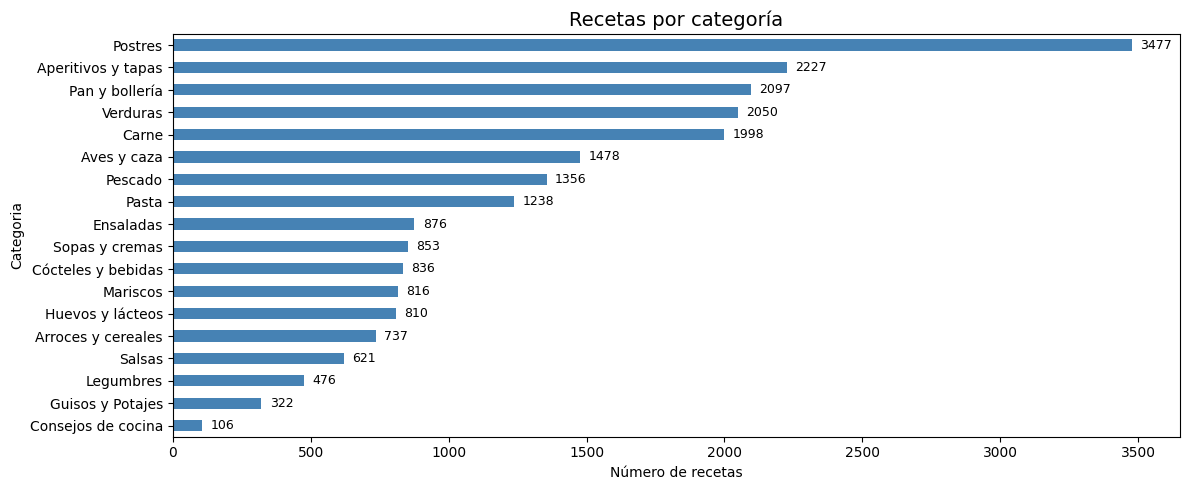

Total recetas: 22374 | Categorías: 18


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
cats = df_raw['Categoria'].value_counts()
cats_clean = cats.rename(lambda x: x.replace('Recetas de ', '').replace('Recetas ', ''))
cats_clean.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Recetas por categoría', fontsize=14)
ax.set_xlabel('Número de recetas')
for i, v in enumerate(cats_clean.sort_values()):
    ax.text(v + 30, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()
print(f'Total recetas: {len(df_raw)} | Categorías: {df_raw["Categoria"].nunique()}')


### 1.3 Análisis de Dificultad


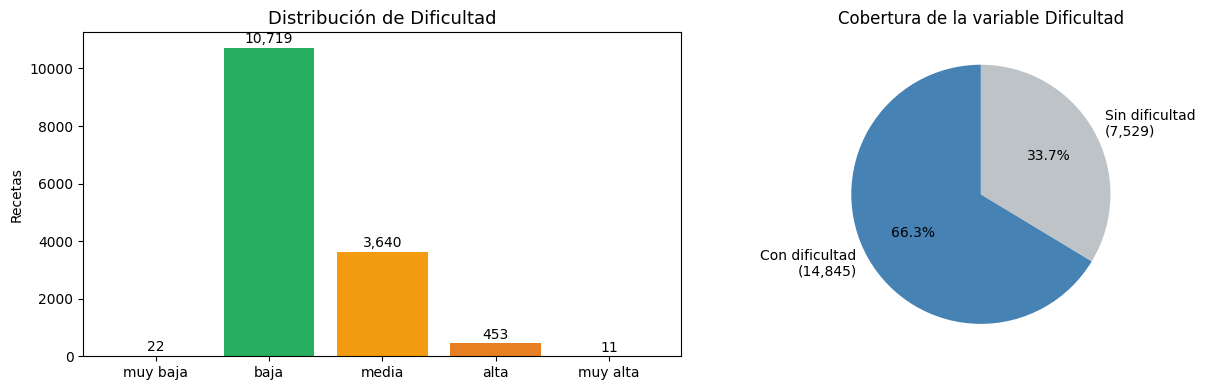

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dif_order = ['muy baja', 'baja', 'media', 'alta', 'muy alta']
dif_counts = df_raw['Dificultad'].value_counts().reindex(dif_order).fillna(0).astype(int)
colors_dif = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[0].bar(dif_counts.index, dif_counts.values, color=colors_dif)
axes[0].set_title('Distribución de Dificultad', fontsize=13)
axes[0].set_ylabel('Recetas')
for bar, val in zip(bars, dif_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

total = len(df_raw)
con_dif = df_raw['Dificultad'].notna().sum()
axes[1].pie([con_dif, total - con_dif],
            labels=[f'Con dificultad\n({con_dif:,})', f'Sin dificultad\n({total-con_dif:,})'],
            colors=['steelblue', '#bdc3c7'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Cobertura de la variable Dificultad')

plt.tight_layout()
plt.show()


### 1.4 Análisis de Tiempo


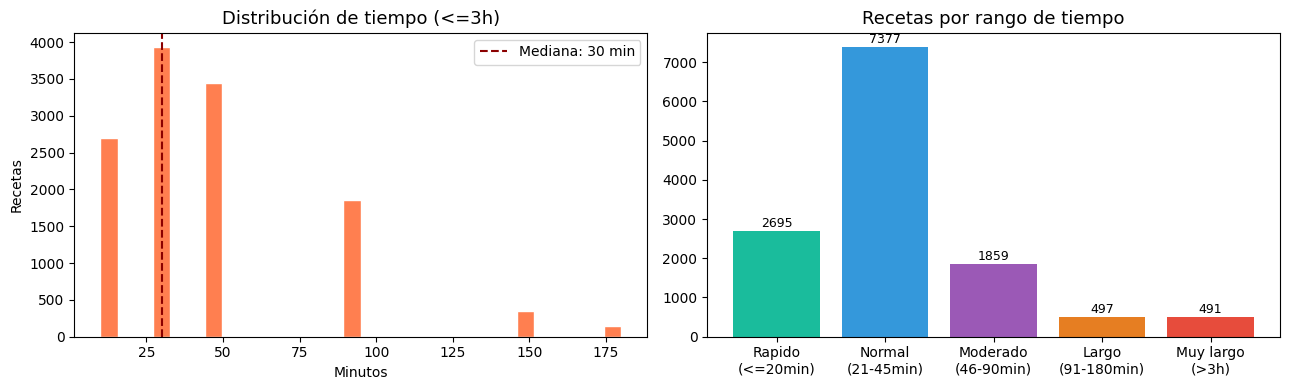

Tiempo: media=70min | mediana=30min | min=10min | max=1440min


In [16]:
# Parser de tiempo a minutos
def parse_tiempo_minutos(t):
    if pd.isna(t) or not t: return None
    t = str(t).lower().strip()
    h_m = re.search(r'(\d+)h', t)
    m_m = re.search(r'(\d+)m', t)
    total = (int(h_m.group(1)) * 60 if h_m else 0) + (int(m_m.group(1)) if m_m else 0)
    return total if total > 0 else None

df_raw['tiempo_min'] = df_raw['Tiempo'].apply(parse_tiempo_minutos)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

t_data = df_raw['tiempo_min'].dropna()
t_clip = t_data[t_data <= 180]
axes[0].hist(t_clip, bins=30, color='coral', edgecolor='white')
axes[0].set_title('Distribución de tiempo (<=3h)', fontsize=13)
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Recetas')
axes[0].axvline(t_data.median(), color='darkred', ls='--',
                label=f'Mediana: {t_data.median():.0f} min')
axes[0].legend()

rangos = pd.cut(t_data,
    bins=[0, 20, 45, 90, 180, 9999],
    labels=['Rapido\n(<=20min)', 'Normal\n(21-45min)', 'Moderado\n(46-90min)',
            'Largo\n(91-180min)', 'Muy largo\n(>3h)'])
r_counts = rangos.value_counts().sort_index()
axes[1].bar(r_counts.index, r_counts.values,
            color=['#1abc9c','#3498db','#9b59b6','#e67e22','#e74c3c'])
axes[1].set_title('Recetas por rango de tiempo', fontsize=13)
for i, (_, val) in enumerate(r_counts.items()):
    axes[1].text(i, val + 30, str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print(f'Tiempo: media={t_data.mean():.0f}min | mediana={t_data.median():.0f}min'
      f' | min={t_data.min():.0f}min | max={t_data.max():.0f}min')


### 1.5 Análisis de Ingredientes


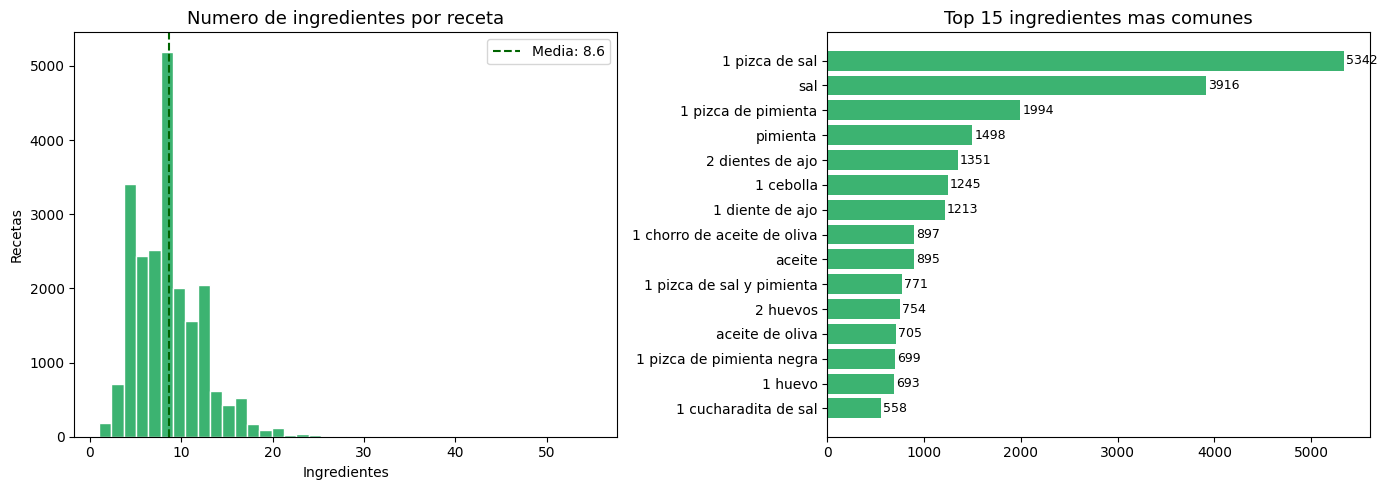

Ingredientes unicos (brutos): 78,376
Media por receta: 8.6 | Mediana: 8


In [17]:
ing_listas = (
    df_raw['Ingredientes'].dropna()
    .str.split(',')
    .apply(lambda lst: [i.strip() for i in lst if i.strip()])
)
n_ings = ing_listas.apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(n_ings, bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Numero de ingredientes por receta', fontsize=13)
axes[0].set_xlabel('Ingredientes')
axes[0].set_ylabel('Recetas')
axes[0].axvline(n_ings.mean(), color='darkgreen', ls='--',
                label=f'Media: {n_ings.mean():.1f}')
axes[0].legend()

all_ings = [i.lower() for sublist in ing_listas for i in sublist]
top_ings = Counter(all_ings).most_common(15)
labels, vals = zip(*top_ings)
axes[1].barh(labels[::-1], vals[::-1], color='mediumseagreen')
axes[1].set_title('Top 15 ingredientes mas comunes', fontsize=13)
for i, v in enumerate(vals[::-1]):
    axes[1].text(v + 20, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'Ingredientes unicos (brutos): {len(set(all_ings)):,}')
print(f'Media por receta: {n_ings.mean():.1f} | Mediana: {n_ings.median():.0f}')


### 1.6 Distribución conjunta: Tiempo × Dificultad


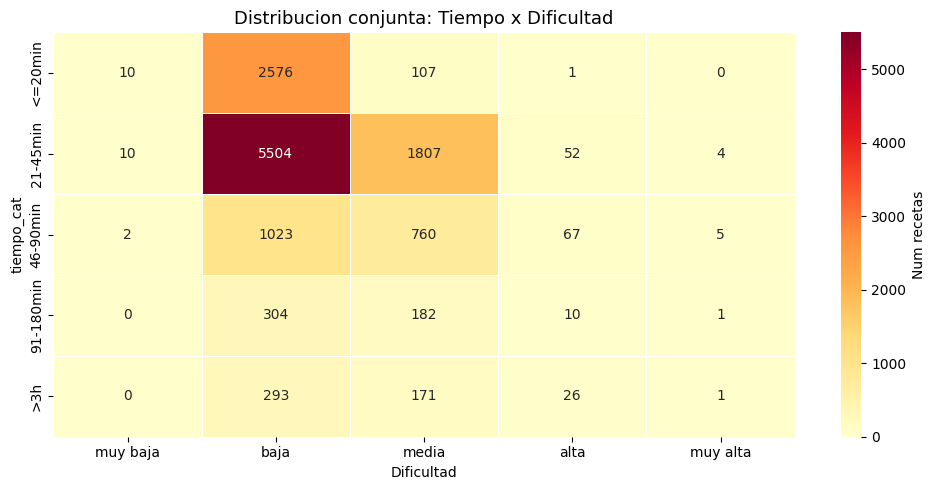

In [18]:
df_cross = df_raw[df_raw['Dificultad'].notna() & df_raw['tiempo_min'].notna()].copy()

dif_order = ['muy baja', 'baja', 'media', 'alta', 'muy alta']
tiempo_bins = pd.cut(df_cross['tiempo_min'],
    bins=[0, 20, 45, 90, 180, 9999],
    labels=['<=20min', '21-45min', '46-90min', '91-180min', '>3h'])
df_cross['tiempo_cat'] = tiempo_bins
df_cross['Dificultad'] = pd.Categorical(df_cross['Dificultad'],
                                          categories=dif_order, ordered=True)

tabla = df_cross.pivot_table(
    index='tiempo_cat', columns='Dificultad',
    values='Id', aggfunc='count', fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(tabla, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Num recetas'})
ax.set_title('Distribucion conjunta: Tiempo x Dificultad', fontsize=13)
plt.tight_layout()
plt.show()


### 1.7 Tipo de plato y Valoración


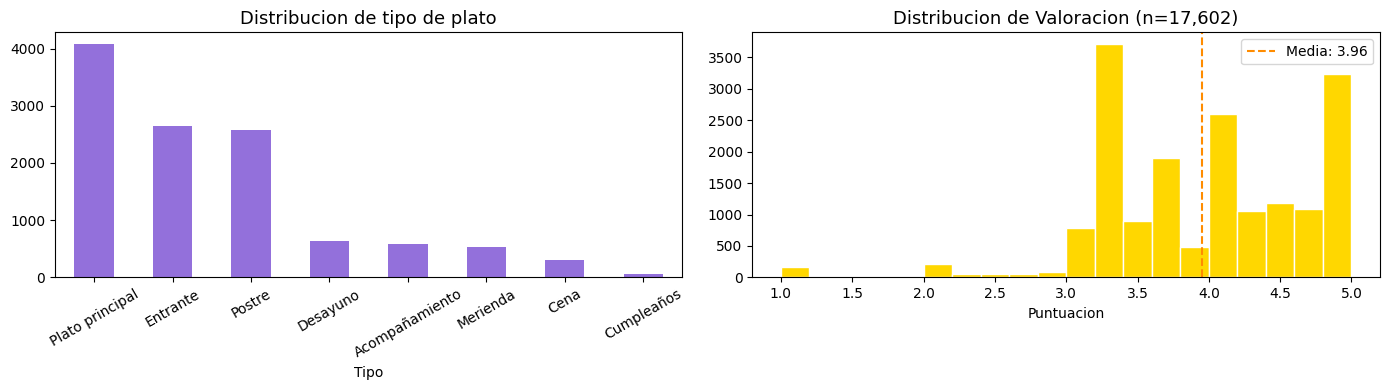

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tipo_counts = df_raw['Tipo'].value_counts().head(10)
tipo_counts.plot(kind='bar', color='mediumpurple', ax=axes[0])
axes[0].set_title('Distribucion de tipo de plato', fontsize=13)
axes[0].tick_params(axis='x', rotation=30)

val_data = df_raw['Valoracion'].dropna()
axes[1].hist(val_data, bins=20, color='gold', edgecolor='white')
axes[1].set_title(f'Distribucion de Valoracion (n={len(val_data):,})', fontsize=13)
axes[1].set_xlabel('Puntuacion')
axes[1].axvline(val_data.mean(), color='darkorange', ls='--',
                label=f'Media: {val_data.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Feature Engineering

Preparamos el dataset para el sistema de búsqueda. Para cada receta se construyen las siguientes variables:

- **`tiempo_minutos`** + **`tiempo_categoria`**: el tiempo se parsea del formato original (`10m`, `1h30m`…) a minutos, y se categoriza en rápido / normal / moderado / largo / muy largo
- **`dificultad_num`**: la dificultad textual (muy baja … muy alta) se codifica como ordinal 1–5 para poder aplicar filtros numéricos en ChromaDB
- **`cant_ingredientes`**: número de ingredientes categorizado en muy pocos / pocos / muchos / muchísimos
- **`ingredientes_norm`**: ingredientes sin cantidades, unidades, modos de cocción ("picado", "rallado"…) ni stopwords — solo el nombre limpio
- **`texto_lexico`**: los ingredientes normalizados unidos en una cadena de tokens, usado como documento en BM25
- **`texto_semantico`**: frase descriptiva completa de la receta (título, categoría, dificultad, tiempo, ingredientes…) usada para generar los embeddings semánticos

Además se descartan las recetas que no tienen tiempo o dificultad informados, quedando el dataset final en 12.840 recetas.


In [8]:
# Funciones auxiliares que se usan en la carga del dataset: limpieza de ingredientes (quita cantidades, unidades, modos de cocción y stopwords), conversión de tiempo a minutos y a categoría, codificación numérica de la dificultad y categorización del número de ingredientes.



UNIDADES = {
    'g','gr','gramo','gramos','kg','ml','litro','litros','dl','cl',
    'taza','tazas','vaso','vasos','cucharada','cucharadas',
    'cucharadita','cucharaditas','cdta','cda','punado','punados',
    'pizca','pizcas','lata','latas','trozo','trozos','rama','ramas',
    'diente','dientes','rodaja','rodajas','sobre','sobres','pellizco',
    'pellizcos','onza','onzas','docena','chorro','chorros',
}
MODOS = {
    'picado','picada','picados','picadas','troceado','troceada',
    'rallado','rallada','cocido','cocida','frito','frita','asado','asada',
    'pelado','pelada','lavado','lavada','seco','seca','fresco','fresca',
    'congelado','congelada','molido','molida','triturado','triturada',
    'hervido','hervida','entero','entera','partido','partida',
    'deshuesado','deshuesada','concentrado','concentrada',
    'grande','grandes','pequeno','pequena','mediano','mediana',
    'al gusto','a gusto','opcional','opcionales','natural','naturales',
}
STOP = {
    'de','del','la','el','los','las','un','una','unos','unas',
    'con','sin','y','o','para','en','a','al','e','por','su','sus',
} | UNIDADES | MODOS

RE_NUM = re.compile(r'\b\d+([.,/]?\d*)\s*\b')
RE_PAR = re.compile(r'\(.*?\)')
RE_SIM = re.compile(r'[^a-z\u00e0-\u00fc\s]', re.IGNORECASE)

DIFICULTAD_NUM = {'muy baja': 1, 'baja': 2, 'media': 3, 'alta': 4, 'muy alta': 5}

def norm_ing(texto: str) -> str:
    s = texto.lower().strip()
    s = RE_PAR.sub(' ', s)
    s = RE_NUM.sub(' ', s)
    s = RE_SIM.sub(' ', s)
    tokens = [t for t in s.split() if t not in STOP and len(t) > 1]
    return ' '.join(tokens).strip()

def norm_lista(ings: list) -> list:
    return [n for ing in ings if (n := norm_ing(ing))]

def tiempo_categoria(minutos) -> str:
    if minutos is None: return 'desconocido'
    if minutos <= 20:   return 'rapido'
    elif minutos <= 45: return 'normal'
    elif minutos <= 90: return 'moderado'
    elif minutos <= 180: return 'largo'
    else:               return 'muy largo'

def parsear_tiempo(t_raw: str) -> Optional[int]:
    t_raw = t_raw.lower()
    h_m = re.search(r'(\d+)h', t_raw)
    m_m = re.search(r'(\d+)m', t_raw)
    total = (int(h_m.group(1)) * 60 if h_m else 0) + (int(m_m.group(1)) if m_m else 0)
    return total if total else None

def cant_ingredientes_cat(ing_raw: list) -> str:
    n = len(ing_raw)
    if n <= 3:    return 'muy pocos'
    elif n <= 7:  return 'pocos'
    elif n <= 14: return 'muchos'
    else:         return 'muchísimos'

In [9]:
# Estructura de datos que representa una receta con todos sus campos procesados. El método build_texts construye los dos textos que usa el sistema de búsqueda: texto_lexico con los ingredientes normalizados para BM25, y texto_semantico con una frase descriptiva completa para los embeddings.


@dataclass
class Recipe:
    id: str
    titulo: str
    ingredientes_raw: list
    ingredientes_norm: list
    categoria: str
    tags: list = field(default_factory=list)
    tiempo_minutos: Optional[int] = None
    tiempo_categoria: str = "desconocido"
    dificultad: Optional[str] = None
    dificultad_num: int = 0
    cant_ingredientes: str = "desconocido"
    porciones: Optional[int] = None
    valoracion: Optional[float] = None
    texto_lexico: str = ""
    texto_semantico: str = ""

    def build_texts(self):
        self.texto_lexico = ' '.join(self.ingredientes_norm)
        partes = [f'{self.titulo} es una receta de {self.categoria}.']
        if self.dificultad:
            partes.append(f'Es de dificultad {self.dificultad}.')
        if self.tiempo_minutos:
            partes.append(f'Se prepara en {self.tiempo_minutos} minutos (preparacion {self.tiempo_categoria}).')
        if self.porciones:
            partes.append(f'Es para {self.porciones} personas.')
        if self.tags:
            partes.append(f'Es un plato de tipo {", ".join(self.tags)}.')
        if self.cant_ingredientes:
            partes.append(f'Tiene {self.cant_ingredientes} ingredientes.')
        if self.ingredientes_norm:
            partes.append(f'Sus ingredientes son: {", ".join(self.ingredientes_norm)}.')
        self.texto_semantico = ' '.join(partes)

In [10]:
# Lee el CSV, aplica todas las transformaciones llamando a las funciones auxiliares y descarta las recetas sin tiempo o dificultad. Devuelve una lista de objetos Recipe listos para usar en el sistema de búsqueda.


def cargar_csv(path: str = 'recetas.csv') -> list:
    recipes, skipped = [], 0
    with open(path, encoding='utf-8', newline='') as f:
        for idx, row in enumerate(csv.DictReader(f, delimiter='|')):
            titulo = (row.get('Nombre') or '').strip()
            if not titulo: skipped += 1; continue

            ing_raw  = [i.strip() for i in (row.get('Ingredientes') or '').split(',') if i.strip()]
            ing_norm = norm_lista(ing_raw)
            if not ing_norm: skipped += 1; continue

            cat = (row.get('Categoria') or 'Sin categoria')
            cat = cat.replace('Recetas de ', '').replace('Recetas ', '').strip()

            tiempo  = parsear_tiempo(row.get('Tiempo') or '')
            dif_raw = (row.get('Dificultad') or '').strip() or None
            dif_num = DIFICULTAD_NUM.get(dif_raw, 0) if dif_raw else 0

            if tiempo is None or dif_raw is None:
                skipped += 1; continue

            tipo       = (row.get('Tipo') or '').strip()
            porc_match = re.search(r'\d+', row.get('Num_comensales', '') or '')
            porciones  = int(porc_match.group()) if porc_match else None
            val_raw    = row.get('Valoracion')
            try:
                valoracion = float(val_raw) if val_raw and str(val_raw).strip() else None
            except ValueError:
                valoracion = None

            r = Recipe(
                id                = f'rec_{idx:05d}_{hashlib.md5(titulo.encode()).hexdigest()[:6]}',
                titulo            = titulo,
                ingredientes_raw  = ing_raw,
                ingredientes_norm = ing_norm,
                categoria         = cat,
                tags              = [tipo] if tipo else [],
                tiempo_minutos    = tiempo,
                tiempo_categoria  = tiempo_categoria(tiempo),
                dificultad        = dif_raw,
                dificultad_num    = dif_num,
                cant_ingredientes = cant_ingredientes_cat(ing_raw),
                porciones         = porciones,
                valoracion        = valoracion,
            )
            r.build_texts()
            recipes.append(r)

    print(f'Cargadas {len(recipes):,} recetas | {skipped} descartadas')
    return recipes

recipes = cargar_csv(CSV_PATH)

Cargadas 12,840 recetas | 9534 descartadas


In [11]:
# Vista previa de los textos construidos
r = recipes[5]
print(f'Titulo:          {r.titulo}')
print(f'Categoria:       {r.categoria}')
print(f'Dificultad:      {r.dificultad} (num={r.dificultad_num})')
print(f'Tiempo:          {r.tiempo_minutos} min ({r.tiempo_categoria})')
print(f'Ings. norm:      {r.ingredientes_norm[:6]}...')
print(f'\nTEXTO LEXICO (BM25):')
print(f'  {r.texto_lexico[:120]}...')
print(f'\nTEXTO SEMANTICO (embeddings):')
print(f'  {r.texto_semantico}')


Titulo:          Receta de Hummus de zanahoria
Categoria:       Aperitivos y tapas
Dificultad:      baja (num=2)
Tiempo:          90 min (moderado)
Ings. norm:      ['zanahorias', 'aceite olivia virgen', 'sal', 'pimentón dulce', 'ajo', 'garbanzos conserva']...

TEXTO LEXICO (BM25):
  zanahorias aceite olivia virgen sal pimentón dulce ajo garbanzos conserva aceite oliva virgen soperas tahina pimentón du...

TEXTO SEMANTICO (embeddings):
  Receta de Hummus de zanahoria es una receta de Aperitivos y tapas. Es de dificultad baja. Se prepara en 90 minutos (preparacion moderado). Es para 6 personas. Es un plato de tipo Entrante. Tiene muchos ingredientes. Sus ingredientes son: zanahorias, aceite olivia virgen, sal, pimentón dulce, ajo, garbanzos conserva, aceite oliva virgen, soperas tahina, pimentón dulce, comino, sal, limón.


## 3. Retrieval Léxico — BM25

**BM25** (Best Match 25) es un modelo probabilístico de recuperación léxica.
Funciona muy bien cuando la query usa los mismos términos que los documentos: ideal para
ingredientes escritos correctamente. No captura semántica ni sinónimos, pero es rápido
y determinista.

El corpus BM25 usa los **ingredientes normalizados** (`texto_lexico`).
Se pueden aplicar filtros de postfiltrado por tiempo y dificultad.


In [ ]:
corpus_tokens = [r.texto_lexico.split() for r in recipes]
bm25 = BM25Okapi(corpus_tokens)
print(f'Indice BM25 construido — {len(corpus_tokens):,} documentos')

Indice BM25 construido — 12,840 documentos


In [ ]:
def buscar_bm25(
    query: str,
    k: int = 10,
    tiempo_max_min: Optional[int] = None,
    dificultad_max: Optional[int] = None,
) -> list:
    terminos     = [q.strip() for q in query.split(',')]
    query_norm   = norm_lista(terminos)
    query_tokens = ' '.join(query_norm).split() if query_norm else query.lower().split()

    scores  = bm25.get_scores(query_tokens)
    top_idx = scores.argsort()[::-1]

    resultados = []
    for idx in top_idx:
        r = recipes[idx]
        s = float(scores[idx])
        if s <= 0: break
        if tiempo_max_min and r.tiempo_minutos and r.tiempo_minutos > tiempo_max_min: continue
        if dificultad_max and r.dificultad_num > dificultad_max: continue
        resultados.append((r, s))
        if len(resultados) >= k: break

    return resultados




def print_resultados(resultados: list):
    """Imprime resultados BM25 con ingredientes originales, sin truncar."""
    for r, s in resultados:
        print(f'  [{s:.3f}] {r.titulo} | {r.dificultad} | {r.tiempo_minutos}min')
        ings_str = ', '.join(r.ingredientes_raw)  # lista legible con cantidades
        for linea in textwrap.wrap(ings_str, width=110):
            print(f'           {linea}')
        print()


# ── Tests ──────────────────────────────────────────────────────────────────────

print('=== BM25 sin filtros ===')
print_resultados(buscar_bm25('tomate, huevo, cebolla, atun', k=5))

print('=== BM25 con filtros: <=30min, dificultad<=2 ===')
print_resultados(buscar_bm25('pollo, patatas, ajo', k=5, tiempo_max_min=30, dificultad_max=2))

print('=== BM25 query abstracta (deberia funcionar MAL) ===')
print_resultados(buscar_bm25('algo dulce con chocolate', k=5))

=== BM25 sin filtros ===
  [5.400] Receta de Potaje de garbanzos con espinacas y huevo duro | baja | 90min
           200 gramos de garbanzos remojados, 1 chorizo, 1 Huevo, 1 tomate, ½ cebolla de huevo blanca, 8 hojas de
           Espinaca, Sal, Pimienta, 1 chorro de Aceite

  [5.358] Receta de Chopitos | baja | 45min
           calamares, Pimiento verde, Pimiento rojo, cebolla, Huevo cocido, Aceitunas, tomate

  [5.358] Receta de Patatas rellenas de carne picada fritas | media | 45min
           2 patatas grandes, 500 gramos de carne picada, 2 dientes de Ajo, ¼ cebolla, 1 cucharada postre de Salsa de
           tomate, 1 Huevo, Harina (opcional)

  [5.358] Receta de Arroz con pisto y huevo | media | 90min
           600 gramos de arroz, 6 Huevo frito, 1 diente de Ajo, 1 pizca de Perejil, 1 cebolla, 1 calabacín, 1 berenjena,
           Salsa de tomate

  [5.178] Receta de Perico criollo con cebolla y tomate | baja | 15min
           8 unidades de Huevo, 2 trozos de cebolla larga, 2 un

## 4. Retrieval Semántico con ChromaDB


Pipeline:
1. Encodear cada receta con su texto semántico → vector denso.
2. Almacenar en **ChromaDB** persistente en disco (`./chroma_harrier`).
3. En búsqueda: encodear la query y recuperar los k vecinos más cercanos por coseno.



ACLARACIÓN: Aqui se pueden observar varias celdas comentadas porque la indexación en espacio vectorial de las recetas se ha ejecutado en la gpu de colab. Entonces una vez indexadas se han guardado en drive y se ha puesto codigo para recuperarlas sin tener que cargarlas más. Luego como parte del notebook requiere modelos locales y usar estas bases vectoriales para el programa final, se han descargado del drive y se ha seguido en local a partir del apartado de UMAP

In [ ]:
import torch
import time
from sentence_transformers import SentenceTransformer
import chromadb
from tqdm import tqdm
import os



device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

MODELOS_CONFIG = {
    'harrier': {
        'model_id':      'microsoft/harrier-oss-v1-0.6b',
        'prefix_query':  'query: ',
        'prefix_passage':'passage: ',
        'chroma_path':   './chroma_harrier',
        'collection':    'recetas_harrier',
    },
    'minilm': {
        'model_id':      'paraphrase-multilingual-MiniLM-L12-v2',
        'prefix_query':  '',   # estos modelos no usan prefijos
        'prefix_passage':'',
        'chroma_path':   './chroma_minilm',
        'collection':    'recetas_minilm',
    },
    'mpnet': {
        'model_id':      'paraphrase-multilingual-mpnet-base-v2',
        'prefix_query':  '',
        'prefix_passage':'',
        'chroma_path':   './chroma_mpnet',
        'collection':    'recetas_mpnet',
    },
    'e5': {
        'model_id':      'intfloat/multilingual-e5-large',
        'prefix_query':  'query: ',     # E5 usa el mismo patrón que Harrier
        'prefix_passage':'passage: ',
        'chroma_path':   './chroma_e5',
        'collection':    'recetas_e5',
    },
}

embedders = {}
for nombre, cfg in MODELOS_CONFIG.items():
    print(f'\nCargando {nombre} ({cfg["model_id"]})...')
    t0 = time.time()
    embedders[nombre] = SentenceTransformer(cfg['model_id'], device=device)
    dim = embedders[nombre].get_sentence_embedding_dimension()
    print(f'  {nombre} cargado — dim={dim} — {time.time()-t0:.1f}s')

Dispositivo: cuda

Cargando harrier (microsoft/harrier-oss-v1-0.6b)...


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 15803.32it/s]


  harrier cargado — dim=1024 — 7.2s

Cargando minilm (paraphrase-multilingual-MiniLM-L12-v2)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5427.84it/s]


  minilm cargado — dim=384 — 5.3s

Cargando mpnet (paraphrase-multilingual-mpnet-base-v2)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8781.71it/s]


  mpnet cargado — dim=768 — 5.7s

Cargando e5 (intfloat/multilingual-e5-large)...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 7908.25it/s]


  e5 cargado — dim=1024 — 6.0s


In [ ]:
####### ESTA CELDA RESTAURA LAS COLECCIIONES YA INDEXADAS DE LA CARPETA DEL COLAB, DESCOMENTAR PARA CARGARLAS

# from google.colab import drive
# import shutil

# drive.mount('/content/drive')

# for nombre in ['chroma_harrier', 'chroma_minilm', 'chroma_mpnet', 'chroma_e5']:
#     src = f'/content/drive/MyDrive/nlp_recetas/{nombre}'
#     dst = f'./{nombre}'
#     print(f'Restaurando {nombre}...')
#     shutil.copytree(src, dst, dirs_exist_ok=True)
#     print(f'  ✓ listo')

# print('\nColecciones restauradas. Puedes saltar las celdas de indexación.')

In [ ]:
# CREACION DE COLECCIONES, NO HACER SI YA ESTÁN GUARDADAS EN DRIVE

chroma_clients = {}
collections = {}

for nombre, cfg in MODELOS_CONFIG.items():
    client = chromadb.PersistentClient(path=cfg['chroma_path'])
    col    = client.get_or_create_collection(
        name=cfg['collection'],
        metadata={'hnsw:space': 'cosine'}
    )
    chroma_clients[nombre] = client
    collections[nombre]    = col
    print(f'{nombre:>8} — colección "{cfg["collection"]}" lista: {col.count():,} recetas indexadas')

 harrier — colección "recetas_harrier" lista: 0 recetas indexadas
  minilm — colección "recetas_minilm" lista: 0 recetas indexadas
   mpnet — colección "recetas_mpnet" lista: 0 recetas indexadas
      e5 — colección "recetas_e5" lista: 0 recetas indexadas


In [33]:
# INDEXACIÓN DE COLECCIONES...


BATCH_SIZE = 512
tiempos_indexacion = {}

for nombre, cfg in MODELOS_CONFIG.items():
    col = collections[nombre]

    if col.count() > 0:
        print(f'{nombre}: ya indexado ({col.count():,} recetas) — saltando')
        tiempos_indexacion[nombre] = None
        continue

    print(f'\n{"="*50}')
    print(f'Indexando {nombre} ({len(recipes):,} recetas)...')
    t_start = time.time()

    for i in tqdm(range(0, len(recipes), BATCH_SIZE), desc=nombre):
        batch     = recipes[i : i + BATCH_SIZE]
        prefix    = cfg['prefix_passage']
        textos    = [prefix + r.texto_semantico for r in batch]
        ids       = [r.id for r in batch]
        metadatas = [{
            'titulo':            r.titulo,
            'categoria':         r.categoria,
            'dificultad':        r.dificultad or '',
            'dificultad_num':    r.dificultad_num,
            'tiempo_minutos':    r.tiempo_minutos or 0,
            'tiempo_categoria':  r.tiempo_categoria,
            'cant_ingredientes': r.cant_ingredientes,
            'porciones':         r.porciones or 0,
        } for r in batch]

        embeddings = embedders[nombre].encode(
            textos, batch_size=64, show_progress_bar=False,
            normalize_embeddings=True
        ).tolist()

        col.add(ids=ids, embeddings=embeddings,
                documents=textos, metadatas=metadatas)

    t_total = time.time() - t_start
    tiempos_indexacion[nombre] = t_total
    print(f'  {col.count():,} recetas indexadas en {t_total:.1f}s ({len(recipes)/t_total:.0f} rec/s)')

print('\n=== RESUMEN TIEMPOS DE INDEXACIÓN ===')
print(f'{"Modelo":<10} {"Tiempo(s)":>10} {"rec/s":>8} {"dim":>6}')
print('-' * 38)
for nombre in MODELOS_CONFIG:
    t = tiempos_indexacion[nombre]
    dim = embedders[nombre].get_sentence_embedding_dimension()
    if t:
        print(f'{nombre:<10} {t:>10.1f} {len(recipes)/t:>8.0f} {dim:>6}')
    else:
        print(f'{nombre:<10} {"(cargado)":>10} {"?":>8} {dim:>6}')


Indexando harrier (12,840 recetas)...


harrier: 100%|██████████| 26/26 [00:58<00:00,  2.26s/it]


  12,840 recetas indexadas en 58.7s (219 rec/s)

Indexando minilm (12,840 recetas)...


minilm: 100%|██████████| 26/26 [00:13<00:00,  1.91it/s]


  12,840 recetas indexadas en 13.6s (943 rec/s)

Indexando mpnet (12,840 recetas)...


mpnet: 100%|██████████| 26/26 [00:25<00:00,  1.03it/s]


  12,840 recetas indexadas en 25.2s (510 rec/s)

Indexando e5 (12,840 recetas)...


e5: 100%|██████████| 26/26 [01:13<00:00,  2.82s/it]

  12,840 recetas indexadas en 73.3s (175 rec/s)

=== RESUMEN TIEMPOS DE INDEXACIÓN ===
Modelo      Tiempo(s)    rec/s    dim
--------------------------------------
harrier          58.7      219   1024
minilm           13.6      943    384
mpnet            25.2      510    768
e5               73.3      175   1024


In [ ]:
#### Esta celda es la que guarda las colecciones indexadas en una carpeta en el drive para no tener que ejecutar todo otra vez
#### descomenta si necesitas guardar cosas hechas en el colab

# from google.colab import drive
# import shutil

# # 1. Monta Drive (te pedirá permisos la primera vez)
# drive.mount('/content/drive')

# # 2. Crea la carpeta en Drive si no existe
# import os
# os.makedirs('/content/drive/MyDrive/nlp_recetas', exist_ok=True)

# # 3. Copia las cuatro colecciones a Drive
# for nombre in ['chroma_harrier', 'chroma_minilm', 'chroma_mpnet', 'chroma_e5']:
#     src = f'./{nombre}'
#     dst = f'/content/drive/MyDrive/nlp_recetas/{nombre}'
#     print(f'Copiando {nombre}...')
#     shutil.copytree(src, dst, dirs_exist_ok=True)
#     print(f'  ✓ {nombre} guardado en Drive')

# print('\nListo. La próxima sesión ejecuta la celda de restauración.')

In [35]:
# Esta celda crea una reconexión con las colecciones porque claro hemos comentado el codigo que crea la variable entonces daba error la celda de busqueda.

# import chromadb

# chroma_clients = {}
# collections = {}

# for nombre, cfg in MODELOS_CONFIG.items():
#     client = chromadb.PersistentClient(path=cfg['chroma_path'])
#     col    = client.get_collection(name=cfg['collection'])  # get, no get_or_create
#     chroma_clients[nombre] = client
#     collections[nombre]    = col
#     print(f'{nombre:>8} — {col.count():,} recetas cargadas')

In [ ]:
def buscar_semantico_modelo(
    query: str,
    nombre_modelo: str,
    k: int = 10,
    tiempo_max_min: Optional[int] = None,
    dificultad_max: Optional[int] = None,
) -> list:
    cfg    = MODELOS_CONFIG[nombre_modelo]
    emb    = embedders[nombre_modelo]
    col    = collections[nombre_modelo]

    prefix = cfg['prefix_query']
    q_emb  = emb.encode([prefix + query], normalize_embeddings=True)[0].tolist()

    filtros = []
    if tiempo_max_min:
        filtros.append({'tiempo_minutos': {'$lte': tiempo_max_min}})
        filtros.append({'tiempo_minutos': {'$gt': 0}})
    if dificultad_max:
        filtros.append({'dificultad_num': {'$lte': dificultad_max}})
        filtros.append({'dificultad_num': {'$gt': 0}})

    where = None
    if len(filtros) == 1:  where = filtros[0]
    elif len(filtros) > 1: where = {'$and': filtros}

    kwargs = {
        'query_embeddings': [q_emb],
        'n_results':        min(k, col.count()),
        'include':          ['distances', 'metadatas', 'documents'],
    }
    if where: kwargs['where'] = where

    results = col.query(**kwargs)
    out = []
    for rid, dist, doc in zip(results['ids'][0], results['distances'][0], results['documents'][0]):
        r = id_to_recipe.get(rid)
        if r:
            out.append((r, round(1.0 - dist, 4), doc))
    return out


def print_semantico(resultados: list):
    """Imprime resultados semánticos con ingredientes completos sin truncar."""
    for r, s, _ in resultados:
        print(f'    [{s:.4f}] {r.titulo} | {r.dificultad} | {r.tiempo_minutos}min')
        ings_str = ', '.join(r.ingredientes_raw)
        for linea in textwrap.wrap(ings_str, width=110):
            print(f'             {linea}')
        print()


# --- Tests comparativos ---
QUERIES_TEST = [
    ('sin filtros',           'tomate, huevo, cebolla, atun',  {}),
    ('con filtros <=30 dif2', 'pollo con patatas',             {'tiempo_max_min': 30, 'dificultad_max': 2}),
    ('query abstracta',       'algo dulce con chocolate',      {}),
]

for desc, query, filtros in QUERIES_TEST:
    print(f'\n{"="*60}')
    print(f'Query: "{query}"  [{desc}]')
    print('='*60)
    for nombre in MODELOS_CONFIG:
        print(f'\n  -- {nombre} --')
        t0 = time.time()
        resultados = buscar_semantico_modelo(query, nombre, k=5, **filtros)
        ms = (time.time() - t0) * 1000
        print_semantico(resultados)
        print(f'    → {ms:.0f}ms')


Query: "tomate, huevo, cebolla, atun"  [sin filtros]

  -- harrier --
    [0.6906] Receta de Tomates rellenos de atún fríos | baja | 30min
             4 tomates de preferencia grandes, 1 lata de atún, 1 cebolla, 1 lata de choclo, 1 palta, 1 puñado de cilantro,
             Hojas de lechuga, Aceite de oliva, Limón (jugo), Sal

    [0.6854] Receta de Tomates rellenos de atún y huevo duro | baja | 30min
             4 tomates, 100 gramos de arvejas/guisantes, 2 huevos duros picados, 1 lata de atún, Aceite de oliva, Hojas de
             lechuga, Perejil, Sal, Pimienta molida, 1 limón, 2 yemas de huevo

    [0.6793] Receta de Ensalada de tomate, cebolla y atún | baja | 10min
             2 tomates para ensalada, 2 cebollas dulces, 2 latas de atún, 1 lata de Olivas rellenas, Aceite, Sal, Vinagre

    [0.6787] Receta de Tomates rellenos de atún | baja | 15min
             6 unidades de tomates, 250 gramos de atún en trozos al natural, 150 gramos de Aceitunas negras (deshuesadas),
         

## 5. Re-ranking

El re-ranking es una **segunda etapa de filtrado** que se aplica sobre los candidatos
ya recuperados por BM25 o los embeddings. En lugar de buscar en toda la colección,
toma los top-k resultados de la primera etapa y los reordena con un modelo más
potente y lento. Esto permite combinar la velocidad del retrieval inicial con la
precisión de modelos más complejos.

Se han evaluado tres rerankers de distinta naturaleza y tamaño:

---

### Cross-Encoders

A diferencia de los bi-encoders usados en el retrieval semántico (que codifican
query y documento por separado), los **cross-encoders** reciben el par
*(query, documento)* concatenado y calculan directamente un score de relevancia.
Esto los hace más precisos pero también más lentos, ya que no pueden precomputar
embeddings.

**`minilm-en`** — `cross-encoder/ms-marco-MiniLM-L-6-v2` (~22M parámetros)
Modelo pequeño entrenado sobre MS-MARCO (corpus de búsqueda en inglés). Se incluye
como **baseline de referencia**: rápido y ligero, pero limitado a inglés, por lo
que su rendimiento sobre recetas en español será el más débil de los tres.

**`bge-v2-m3`** — `BAAI/bge-reranker-v2-m3` (~568M parámetros)
Cross-encoder multilingüe, actualmente uno de los estándares en pipelines RAG en
producción. Soporta español de forma nativa, lo que lo convierte en el candidato
más sólido para este corpus. Su mayor tamaño respecto a MiniLM se traduce en mejor
comprensión del contexto y mayor precisión en el reordenamiento.



**`f2llm-4b`** — `codefuse-ai/F2LLM-v2-4B` (~4B parámetros)
Enfoque distinto: en lugar de un modelo entrenado específicamente para ranking,
se usa un **LLM generativo de 4B parámetros** al que se le formula la relevancia
como una pregunta de sí/no. Dado el par *(query, receta)*, el modelo genera una
respuesta y se extraen los logits de los tokens `Yes` y `No` para calcular la
probabilidad de relevancia:


In [37]:
from sentence_transformers import CrossEncoder
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

RERANKERS_CONFIG = {
    'minilm-en': {
        'model_id':     'cross-encoder/ms-marco-MiniLM-L-6-v2',
        'tipo':         'cross-encoder',
        'params':       '~22M',
        'nota':         'EN-only, baseline pequeño',
    },
    'bge-v2-m3': {
        'model_id':     'BAAI/bge-reranker-v2-m3',
        'tipo':         'cross-encoder',
        'params':       '~568M',
        'nota':         'multilingüe, estándar RAG actual',
    },
    'f2llm-4b': {
        'model_id':     'codefuse-ai/F2LLM-v2-4B',
        'tipo':         'llm-pointwise',
        'params':       '~4B',
        'nota':         'LLM generativo como reranker pointwise (Yes/No logits)',
    },
}

rerankers = {}

for nombre, cfg in RERANKERS_CONFIG.items():
    print(f'\nCargando {nombre} ({cfg["model_id"]}, {cfg["params"]})...')
    t0 = time.time()

    if cfg['tipo'] == 'cross-encoder':
        kwargs = {'max_length': 512, 'device': device}
        kwargs.update(cfg.get('extra_kwargs', {}))
        rerankers[nombre] = CrossEncoder(cfg['model_id'], **kwargs)

    elif cfg['tipo'] == 'llm-pointwise':
        bnb_config = None
        if device == 'cuda':
            try:
                bnb_config = BitsAndBytesConfig(
                    load_in_4bit=True,
                    bnb_4bit_compute_dtype=torch.float16,
                    bnb_4bit_use_double_quant=True,
                    bnb_4bit_quant_type='nf4',
                )
            except Exception:
                bnb_config = None

        tokenizer = AutoTokenizer.from_pretrained(cfg['model_id'], trust_remote_code=True)
        model = AutoModelForCausalLM.from_pretrained(
            cfg['model_id'],
            quantization_config=bnb_config,
            torch_dtype=torch.float16 if device == 'cuda' else torch.float32,
            device_map='auto' if device == 'cuda' else 'cpu',
            trust_remote_code=True,
        )
        model.eval()

        # IDs de los tokens "Yes" y "No" (se calculan una sola vez)
        yes_id = tokenizer.encode('Yes', add_special_tokens=False)[-1]
        no_id  = tokenizer.encode('No',  add_special_tokens=False)[-1]

        rerankers[nombre] = {
            'tokenizer': tokenizer,
            'model':     model,
            'yes_id':    yes_id,
            'no_id':     no_id,
            'cache':     {},
        }

    print(f'  {nombre} cargado — {time.time()-t0:.1f}s')


Cargando minilm-en (cross-encoder/ms-marco-MiniLM-L-6-v2, ~22M)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5606.36it/s]


  minilm-en cargado — 9.5s

Cargando bge-v2-m3 (BAAI/bge-reranker-v2-m3, ~568M)...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 10180.98it/s]


  bge-v2-m3 cargado — 31.4s

Cargando f2llm-4b (codefuse-ai/F2LLM-v2-4B, ~4B)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
W0524 09:49:03.742000 24012 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights: 100%|██████████| 398/398 [00:02<00:00, 150.97it/s]


  f2llm-4b cargado — 109.3s


In [38]:
def score_pares_rerank(reranker_name: str, query: str, docs: list, recetas: list = None) -> list:
    cfg = RERANKERS_CONFIG[reranker_name]
    rk  = rerankers[reranker_name]

    if cfg['tipo'] == 'cross-encoder':
        pares = [(query, d) for d in docs]
        return [float(s) for s in rk.predict(pares, show_progress_bar=False)]

    elif cfg['tipo'] == 'llm-pointwise':
        tokenizer = rk['tokenizer']
        model     = rk['model']
        yes_id    = rk['yes_id']
        no_id     = rk['no_id']
        cache     = rk['cache']

        scores = []
        for i, doc in enumerate(docs):
            cache_key = (query, recetas[i].id) if recetas else (query, doc)
            if cache_key in cache:
                scores.append(cache[cache_key])
                continue

            prompt = (
                f'Given the user query: "{query}"\n'
                f'Is the following recipe relevant to the query? '
                f'Answer only "Yes" or "No".\n'
                f'Recipe: {doc}\n'
                f'Answer:'
            )
            inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
            with torch.no_grad():
                logits = model(**inputs).logits[:, -1, :]
            yes_no = logits[0, [yes_id, no_id]].float()
            probs  = torch.softmax(yes_no, dim=0)
            score  = probs[0].item()

            cache[cache_key] = score
            scores.append(score)
        return scores


def rerank_con(reranker_name: str, query: str, candidatos: list, k: int = 5) -> list:
    if not candidatos:
        return []

    recetas = [cand[0] for cand in candidatos]
    # Texto completo: el mismo que vio el embedder en la indexación
    docs = [r.texto_semantico for r in recetas]

    scores   = score_pares_rerank(reranker_name, query, docs, recetas=recetas)
    rescored = sorted(zip(recetas, scores), key=lambda x: x[1], reverse=True)
    return rescored[:k]


def buscar_con_rerank(
    query: str,
    reranker_name: str,
    modelo_retrieval: str = 'e5',
    k_first: int = 20,
    k_final: int = 5,
    tiempo_max_min: Optional[int] = None,
    dificultad_max: Optional[int] = None,
) -> list:
    if modelo_retrieval == 'bm25':
        candidatos = buscar_bm25(query, k=k_first,
                                  tiempo_max_min=tiempo_max_min,
                                  dificultad_max=dificultad_max)
    else:
        candidatos = buscar_semantico_modelo(query, modelo_retrieval, k=k_first,
                                              tiempo_max_min=tiempo_max_min,
                                              dificultad_max=dificultad_max)
    return rerank_con(reranker_name, query, candidatos, k=k_final)

Esta celda compara la recuperación de diferentes queries con el modelo que mejor ha salido de embeddings arriba (e5) con diferentes cross encoders

In [51]:
QUERIES_TEST = [
    'tomate, huevo, cebolla, atun',
    'algo dulce con chocolate',
    'pollo con patatas y ajo',
    'cena ligera de verano',
    'pasta rapida con marisco',
]

RETRIEVAL = 'e5'
K_FIRST   = 20
K_FINAL   = 5

latencias = {nombre: [] for nombre in RERANKERS_CONFIG}

# Helper: imprime una receta con su descripción semántica completa
def print_receta(score, receta, prefijo='    '):
    print(f'{prefijo}[{score:.4f}] {receta.titulo} | {receta.dificultad} | {receta.tiempo_minutos}min')
    print(f'{prefijo}        {receta.texto_semantico}')


for query in QUERIES_TEST:
    print(f'\n{"="*80}')
    print(f'Query: "{query}"')
    print('='*80)

    cand_base = buscar_semantico_modelo(query, RETRIEVAL, k=K_FIRST)

    print(f'\n  -- {RETRIEVAL} (sin rerank) --')
    for r, s, _ in cand_base[:K_FINAL]:
        print_receta(s, r)

    for nombre in RERANKERS_CONFIG:
        t0 = time.time()
        resultados = rerank_con(nombre, query, cand_base, k=K_FINAL)
        ms = (time.time() - t0) * 1000
        latencias[nombre].append(ms)
        params = RERANKERS_CONFIG[nombre]['params']
        print(f'\n  -- {RETRIEVAL} + {nombre} ({params}, {ms:.0f}ms) --')
        for r, s in resultados:
            print_receta(s, r)


print(f'\n{"="*50}')
print(f'LATENCIA MEDIA POR RERANKER (k_first={K_FIRST}, n={len(QUERIES_TEST)} queries)')
print('='*50)
print(f'{"Reranker":<15} {"Params":<10} {"ms/query":>10}')
print('-' * 38)
for nombre in RERANKERS_CONFIG:
    media = sum(latencias[nombre]) / len(latencias[nombre])
    params = RERANKERS_CONFIG[nombre]['params']
    print(f'{nombre:<15} {params:<10} {media:>10.0f}')


Query: "tomate, huevo, cebolla, atun"

  -- e5 (sin rerank) --
    [0.8475] Receta de Ensalada de tomate, cebolla y atún | baja | 10min
            Receta de Ensalada de tomate, cebolla y atún es una receta de Ensaladas. Es de dificultad baja. Se prepara en 10 minutos (preparacion rapido). Es para 4 personas. Es un plato de tipo Entrante. Tiene pocos ingredientes. Sus ingredientes son: tomates ensalada, cebollas dulces, atún, olivas rellenas, aceite, sal, vinagre.
    [0.8456] Receta de Huevos rellenos con atun y salsa de tomate | baja | 30min
            Receta de Huevos rellenos con atun y salsa de tomate es una receta de Huevos y lácteos. Es de dificultad baja. Se prepara en 30 minutos (preparacion normal). Es para 12 personas. Es un plato de tipo Entrante. Tiene pocos ingredientes. Sus ingredientes son: unidades huevo, atún, mayonesa, bote tomate.
    [0.8452] Receta de Tomates rellenos de atún y huevo duro | baja | 30min
            Receta de Tomates rellenos de atún y huevo duro

Como se puede observar que los cross encoders no mejoran mucho los resultados del e5 se ha probado a aplicarlos al BM25 léxico en esta celda a continuación

In [50]:
QUERIES_TEST = [
    'tomate, huevo, cebolla, atun',
    'algo dulce con chocolate',
    'pollo con patatas y ajo',
    'cena ligera de verano',
    'pasta rapida con marisco',
]

RETRIEVAL = 'bm25'
K_FIRST   = 30
K_FINAL   = 5

latencias = {nombre: [] for nombre in RERANKERS_CONFIG}

def print_receta(score, receta, prefijo='    '):
    print(f'{prefijo}[{score:.4f}] {receta.titulo} | {receta.dificultad} | {receta.tiempo_minutos}min')
    print(f'{prefijo}        {receta.texto_semantico}')


for query in QUERIES_TEST:
    print(f'\n{"="*80}')
    print(f'Query: "{query}"')
    print('='*80)

    if RETRIEVAL == 'bm25':
        cand_base = [(r, s, r.texto_semantico) for r, s in buscar_bm25(query, k=K_FIRST)]
    else:
        cand_base = buscar_semantico_modelo(query, RETRIEVAL, k=K_FIRST)

    print(f'\n  -- {RETRIEVAL} (sin rerank) --')
    for r, s, _ in cand_base[:K_FINAL]:
        print_receta(s, r)

    for nombre in RERANKERS_CONFIG:
        t0 = time.time()
        resultados = rerank_con(nombre, query, cand_base, k=K_FINAL)
        ms = (time.time() - t0) * 1000
        latencias[nombre].append(ms)
        params = RERANKERS_CONFIG[nombre]['params']
        print(f'\n  -- {RETRIEVAL} + {nombre} ({params}, {ms:.0f}ms) --')
        for r, s in resultados:
            print_receta(s, r)


print(f'\n{"="*50}')
print(f'LATENCIA MEDIA POR RERANKER (k_first={K_FIRST}, n={len(QUERIES_TEST)} queries)')
print('='*50)
print(f'{"Reranker":<15} {"Params":<10} {"ms/query":>10}')
print('-' * 38)
for nombre in RERANKERS_CONFIG:
    media = sum(latencias[nombre]) / len(latencias[nombre])
    params = RERANKERS_CONFIG[nombre]['params']
    print(f'{nombre:<15} {params:<10} {media:>10.0f}')


Query: "tomate, huevo, cebolla, atun"

  -- bm25 (sin rerank) --
    [5.4004] Receta de Potaje de garbanzos con espinacas y huevo duro | baja | 90min
            Receta de Potaje de garbanzos con espinacas y huevo duro es una receta de Legumbres. Es de dificultad baja. Se prepara en 90 minutos (preparacion moderado). Es para 1 personas. Es un plato de tipo Plato principal. Tiene muchos ingredientes. Sus ingredientes son: garbanzos remojados, chorizo, huevo, tomate, cebolla huevo blanca, hojas espinaca, sal, pimienta, aceite.
    [5.3582] Receta de Chopitos | baja | 45min
            Receta de Chopitos es una receta de Mariscos. Es de dificultad baja. Se prepara en 45 minutos (preparacion normal). Es para 2 personas. Tiene pocos ingredientes. Sus ingredientes son: calamares, pimiento verde, pimiento rojo, cebolla, huevo, aceitunas, tomate.
    [5.3582] Receta de Patatas rellenas de carne picada fritas | media | 45min
            Receta de Patatas rellenas de carne picada fritas es una 

### 6.1 Visualización UMAP del espacio semántico


Muestra y embeddings

In [40]:
import umap

# Muestra estratificada (la misma para todos los modelos, así son comparables)
random.seed(SEED)
por_categoria = defaultdict(list)
for r in recipes: por_categoria[r.categoria].append(r)

muestra_umap = []
for cat, recs in por_categoria.items():
    muestra_umap.extend(random.sample(recs, min(150, len(recs))))

ids_umap = [r.id for r in muestra_umap]
print(f'Muestra UMAP: {len(muestra_umap)} recetas de {len(por_categoria)} categorias')

# Recupera embeddings de cada colección
embs_por_modelo = {}
for nombre in MODELOS_CONFIG:
    res = collections[nombre].get(ids=ids_umap, include=['embeddings'])
    embs_por_modelo[nombre] = np.array(res['embeddings'])
    print(f'  {nombre:>8}: shape {embs_por_modelo[nombre].shape}')

Muestra UMAP: 2502 recetas de 17 categorias
   harrier: shape (2502, 1024)
    minilm: shape (2502, 384)
     mpnet: shape (2502, 768)
        e5: shape (2502, 1024)


Cálculo UMAP

In [41]:
proyecciones = {}
reducers     = {}

for nombre, embs in embs_por_modelo.items():
    print(f'Calculando UMAP de {nombre}...')
    t0 = time.time()
    reducer = umap.UMAP(
        n_components=2, metric='cosine',
        random_state=SEED, n_neighbors=15, min_dist=0.1
    )
    proyecciones[nombre] = reducer.fit_transform(embs)
    reducers[nombre]     = reducer
    print(f'  hecho en {time.time()-t0:.1f}s')

Calculando UMAP de harrier...
  hecho en 13.4s
Calculando UMAP de minilm...
  hecho en 5.0s
Calculando UMAP de mpnet...
  hecho en 5.7s
Calculando UMAP de e5...
  hecho en 6.0s


In [42]:
dfs_umap = {}
for nombre, proj in proyecciones.items():
    dfs_umap[nombre] = pd.DataFrame({
        'x':          proj[:, 0],
        'y':          proj[:, 1],
        'titulo':     [r.titulo for r in muestra_umap],
        'categoria':  [r.categoria for r in muestra_umap],
        'dificultad': [r.dificultad or 'desconocida' for r in muestra_umap],
        'tiempo':     [f'{r.tiempo_minutos}min' if r.tiempo_minutos else '?' for r in muestra_umap],
    })

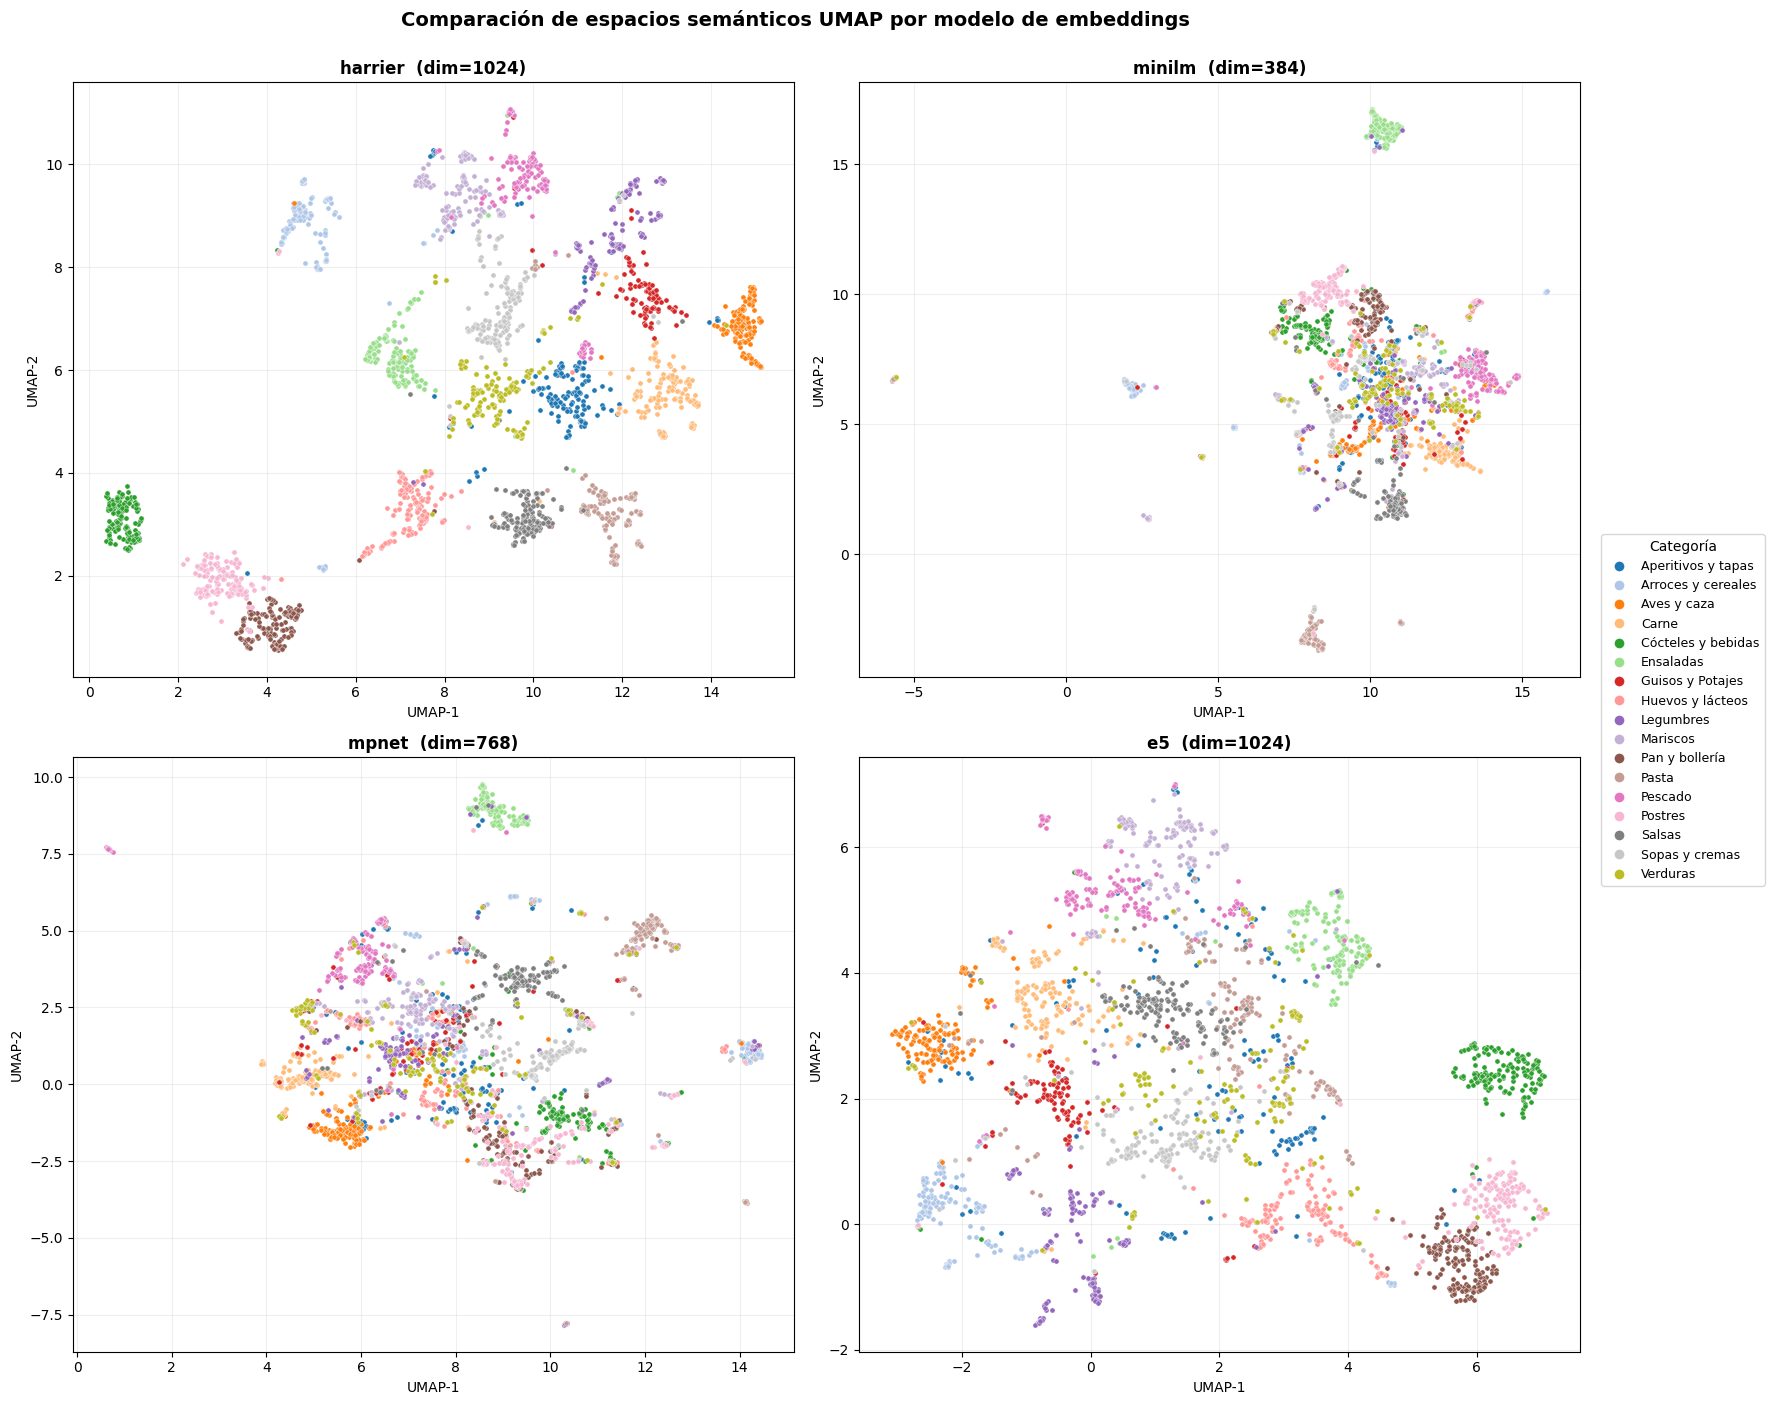

In [43]:
# Categorías y paleta compartidas (consistencia visual entre los 4 plots)
categorias = sorted(dfs_umap[next(iter(dfs_umap))]['categoria'].unique())
palette    = sns.color_palette('tab20', n_colors=len(categorias))
color_map  = dict(zip(categorias, palette))

modelos_lista = list(MODELOS_CONFIG.keys())
n             = len(modelos_lista)
ncols         = 2
nrows         = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7 * nrows))
axes = axes.flatten()

for ax, nombre in zip(axes, modelos_lista):
    df = dfs_umap[nombre]
    dim = embedders[nombre].get_sentence_embedding_dimension()

    for cat in categorias:
        sub = df[df['categoria'] == cat]
        ax.scatter(sub['x'], sub['y'], s=14, alpha=1.0,
                   color=color_map[cat], label=cat,
                   edgecolors='white', linewidths=0.3)

    ax.set_title(f'{nombre}  (dim={dim})', fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.grid(alpha=0.2)

# Apaga los axes sobrantes si hay
for ax in axes[len(modelos_lista):]:
    ax.axis('off')

# Una sola leyenda compartida fuera, a la derecha
handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color_map[cat], markersize=8, label=cat)
           for cat in categorias]
fig.legend(handles=handles, title='Categoría',
           bbox_to_anchor=(1.0, 0.5), loc='center left', fontsize=9)

fig.suptitle('Comparación de espacios semánticos UMAP por modelo de embeddings',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

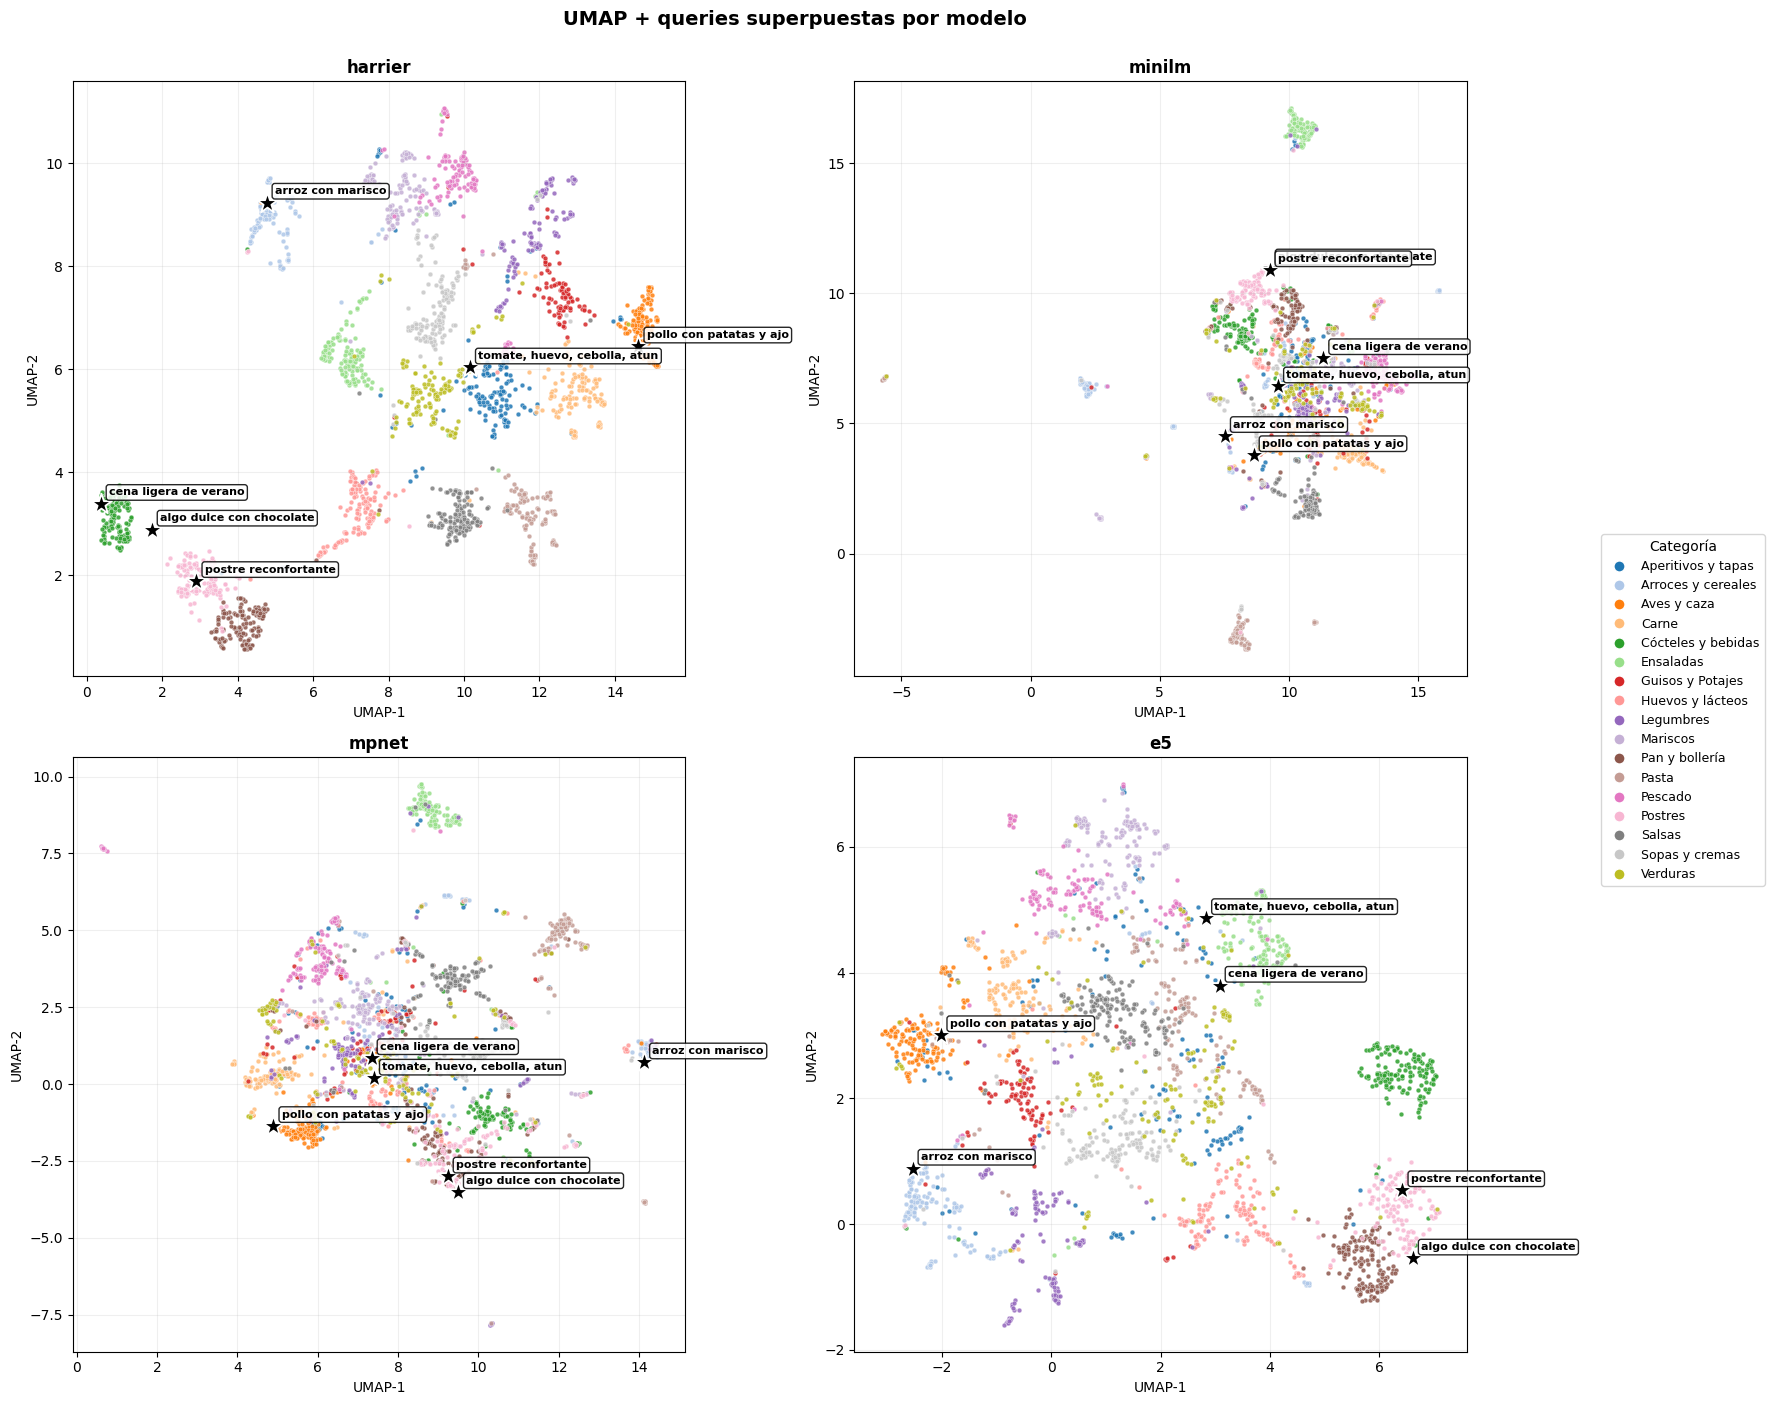

In [44]:
queries_viz = [
    'tomate, huevo, cebolla, atun',
    'algo dulce con chocolate',
    'cena ligera de verano',
    'arroz con marisco',
    'postre reconfortante',
    'pollo con patatas y ajo',
]

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7 * nrows))
axes = axes.flatten()

for ax, nombre in zip(axes, modelos_lista):
    df       = dfs_umap[nombre]
    cfg      = MODELOS_CONFIG[nombre]
    embedder = embedders[nombre]
    reducer  = reducers[nombre]

    # Proyectar queries en el espacio UMAP de este modelo
    embs_q = embedder.encode([cfg['prefix_query'] + q for q in queries_viz],
                              normalize_embeddings=True)
    proj_q = reducer.transform(embs_q)

    # Recetas en el fondo
    for cat in categorias:
        sub = df[df['categoria'] == cat]
        ax.scatter(sub['x'], sub['y'], s=12, alpha=0.85,
                   color=color_map[cat], edgecolors='white', linewidths=0.3)

    # Queries como estrellas
    ax.scatter(proj_q[:, 0], proj_q[:, 1],
               s=240, marker='*', color='black',
               edgecolors='white', linewidths=1.3, zorder=10)

    for (x, y), q in zip(proj_q, queries_viz):
        ax.annotate(q, (x, y), xytext=(6, 6), textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.25',
                              facecolor='white', edgecolor='black', alpha=0.85),
                    zorder=11)

    ax.set_title(f'{nombre}', fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.grid(alpha=0.2)

for ax in axes[len(modelos_lista):]:
    ax.axis('off')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color_map[cat], markersize=8, label=cat)
           for cat in categorias]
fig.legend(handles=handles, title='Categoría',
           bbox_to_anchor=(1.0, 0.5), loc='center left', fontsize=9)

fig.suptitle('UMAP + queries superpuestas por modelo',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

CONCLUSIONES

**BM25 (léxico)** recupera recetas que contienen exactamente los términos de la query. Funciona bien cuando hay coincidencia directa. Falla cuando algún ingrediente clave tiene poco peso relativo: con "tomate, huevo, cebolla, atún" no aparece ninguna receta con atún en el top 5 porque los documentos cortos con tomate+huevo+cebolla puntúan más alto por la normalización de longitud de BM25. Con filtros también falla, el top resultado de "pollo, patatas, ajo" son unas salchichas que simplemente tienen pocos ingredientes y los que coinciden pesan más.

**Embeddings semánticos (E5)** es el mejor modelo para este caso de uso. Representa query y recetas en un espacio vectorial donde la similitud captura tanto coincidencias léxicas como relaciones entre términos, lo que le da más robustez ante queries donde BM25 pierde ingredientes específicos por el peso relativo. Los otros modelos (MiniLM, MPNet, Harrier) pierden ingredientes discriminantes como el atún o generalizan demasiado hacia categorías amplias.

**Reranking sobre E5** No aporta mejora apreciable, los resultados ya son los más relevantes sin él, a costa de latencia extra. Sobre BM25 sí mejora con `bge-v2-m3`, pero el punto de partida sigue siendo peor que E5 directo.

**Conclusión: E5 sin reranking es la mejor opción** para este sistema — mejor precisión sin complejidad añadida.

# 7 QUERY NORMALIZATION

A partir de aqui como ya hemos comprobado que los embeddings de E5 son de entre los probados el que mejores resultados ofrece vamos a probar otras técnicas de cara a mejorar el programa de recuperación de recetas

In [54]:
OLLAMA_BASE_URL = "http://localhost:11434/v1"
OLLAMA_API_KEY  = "ollama"   # lo ignora pero el SDK lo exige

ollama_client = OpenAI(
    base_url=OLLAMA_BASE_URL,
    api_key=OLLAMA_API_KEY,
)

# Verificar que Ollama está corriendo y ver qué modelos hay
modelos = ollama_client.models.list()
print([m.id for m in modelos.data])

['qwen2.5:3b']


In [55]:
OLLAMA_MODEL = "qwen2.5:3b"

In [56]:
SYSTEM_PROMPT_NORMALIZACION = """
Eres un normalizador de consultas para un buscador de recetas de cocina.

El usuario te va a pasar texto libre. Tu trabajo es devolver SIEMPRE un JSON con este formato exacto y nada más:
{"valida": true, "ingredientes": ["ingrediente1", "ingrediente2"]}
o
{"valida": false, "motivo": "explicación breve"}

REGLAS:

1. Si el texto tiene ingredientes bien escritos → devuélvelos limpios, en minúsculas, sin cantidades ni unidades.
   Ejemplo: "2 pechugas de pollo, 3 patatas y ajo" → {"valida": true, "ingredientes": ["pollo", "patatas", "ajo"]}

2. Si hay errores ortográficos o palabras cortadas → corrígelos.
   Ejemplo: "tomattes, jamob, quesoo" → {"valida": true, "ingredientes": ["tomates", "jamón", "queso"]}
   Ejemplo: "pol, patatas, ajoo" → {"valida": true, "ingredientes": ["pollo", "patatas", "ajo"]}

3. Si la consulta es abstracta (sabor, ocasión, emoción) → tradúcela a ingredientes concretos buscables.
   Ejemplo: "quiero algo dulce" → {"valida": true, "ingredientes": ["azúcar", "chocolate", "harina", "mantequilla"]}
   Ejemplo: "cena ligera de verano" → {"valida": true, "ingredientes": ["ensalada", "pollo", "pescado", "verduras"]}
   Ejemplo: "algo reconfortante" → {"valida": true, "ingredientes": ["caldo", "patatas", "legumbres", "carne"]}

4. Si no tiene nada que ver con comida ni recetas → invalida.
   Ejemplo: "cuánto mide la Torre Eiffel" → {"valida": false, "motivo": "No está relacionado con recetas o ingredientes"}

IMPORTANTE: responde SOLO con el JSON. Sin texto extra, sin markdown, sin comillas adicionales.
""".strip()

print("Prompt cargado")

Prompt cargado


In [ ]:
# Cuidado con poner un max tokens o algo y usar un modelo de thinking porque entonces se chupa los tokens pensando antes de dar respuesta y no devuelve nada
def normalizar_query(query: str) -> dict:
    respuesta = ollama_client.chat.completions.create(
        model=OLLAMA_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_NORMALIZACION},
            {"role": "user",   "content": query},
        ],
        temperature=0.1
    )

    raw = respuesta.choices[0].message.content.strip()
    print(f"Raw LLM: {raw}")

    # Por si el modelo mete backticks o texto extra alrededor
    json_match = re.search(r'\{.*\}', raw, re.DOTALL)
    return json.loads(json_match.group())

print("Función cargada")

Función cargada


In [59]:
casos = [
    "tomattes, jamob, quesoo",
    "pol, patatas, ajoo",
    "quiero algo dulce",
    "cena ligera de verano",
    "pollo, patatas, ajo",
    "¿cuánto mide la Torre Eiffel?",
]

for q in casos:
    print(f"\nEntrada: {q}")
    r = normalizar_query(q)
    print(f"Salida:  {r}")


Entrada: tomattes, jamob, quesoo
Raw LLM: {"valida": true, "ingredientes": ["tomates", "jamón", "queso"]}
Salida:  {'valida': True, 'ingredientes': ['tomates', 'jamón', 'queso']}

Entrada: pol, patatas, ajoo
Raw LLM: {"valida": true, "ingredientes": ["pollo", "patatas", "ajo"]}
Salida:  {'valida': True, 'ingredientes': ['pollo', 'patatas', 'ajo']}

Entrada: quiero algo dulce
Raw LLM: {"valida": true, "ingredientes": ["azúcar", "chocolate", "harina", "mantequilla"]}
Salida:  {'valida': True, 'ingredientes': ['azúcar', 'chocolate', 'harina', 'mantequilla']}

Entrada: cena ligera de verano
Raw LLM: {"valida": true, "ingredientes": ["ensalada", "pollo", "pescado", "verduras"]}
Salida:  {'valida': True, 'ingredientes': ['ensalada', 'pollo', 'pescado', 'verduras']}

Entrada: pollo, patatas, ajo
Raw LLM: {"valida": true, "ingredientes": ["pollo", "patatas", "ajo"]}
Salida:  {'valida': True, 'ingredientes': ['pollo', 'patatas', 'ajo']}

Entrada: ¿cuánto mide la Torre Eiffel?
Raw LLM: {"valida

Se puede comprobar que un modelo pequeño es capaz de desempeñar correctamente la tarea de normalizar errores ortográficos o preguntas sin sentido y aterrizar los ingredientes o platos preguntados listos para la búsqueda. Además para queries más difíciles o abstractas sirve para sugerir indredientes o platos previo a la búsqueda.

# 8 Pipeline de audio

In [78]:
import sounddevice as sd
import soundfile as sf
import IPython.display as ipd

AUDIO_PATH = "audio_query.wav"

print("Grabando 5 segundos...")
audio = sd.rec(int(5 * 16000), samplerate=16000, channels=1, dtype='float32')
sd.wait()
sf.write(AUDIO_PATH, audio, 16000)
print("✅ Grabación guardada\n")

print("Audio grabado:")
ipd.display(ipd.Audio(AUDIO_PATH, embed=True))

Grabando 5 segundos...
✅ Grabación guardada

Audio grabado:


In [ ]:
AUDIO_PATH = "audio_query.wav"

print("Cargando modelo Whisper...")
whisper_model = whisper.load_model("small")

print("Transcribiendo audio...")
result = whisper_model.transcribe(AUDIO_PATH, language="es")
query_raw = result["text"].strip()

print(f"\n✅ Transcripción:")
print(f'   "{query_raw}"')

Cargando modelo Whisper...
Transcribiendo audio...

✅ Transcripción:
   "Tengo un limón, un filete de pollo y ajo."


In [ ]:
print(f"Query raw: {query_raw}")
print("Normalizando con LLM...")

resultado_llm = normalizar_query(query_raw)
print(f"LLM output: {resultado_llm}")

if resultado_llm.get("valida"):
    query_final = ', '.join(resultado_llm["ingredientes"])
    print(f"\n✅ Query normalizada: {query_final}")
else:
    print(f"\n⚠️ Query inválida: {resultado_llm.get('motivo')}")
    query_final = query_raw  # fallback por si el LLM falla

print(f"\nQuery que se usará para buscar: {query_final}")

Query raw: Tengo un limón, un filete de pollo y ajo.
Normalizando con LLM...
Raw LLM: {"valida": true, "ingredientes": ["limon", "pollo", "ajo"]}
LLM output: {'valida': True, 'ingredientes': ['limon', 'pollo', 'ajo']}

✅ Query normalizada: limon, pollo, ajo

Query que se usará para buscar: limon, pollo, ajo


Como queremos que la respuesta sea un audio fluido como de una persona que ha encontrado lo que le has pedido que busque tenemos que meter un llm que genere el texto que kokoro se va encargar a traducir a audio, ya que si no el audio será simplemente el resultado de la recuperación.

In [ ]:
print(f'Buscando recetas para: "{query_final}"\n')

resultados = buscar_con_rerank(
    query            = query_final,
    reranker_name    = 'bge-v2-m3',
    modelo_retrieval = 'e5',
    k_first          = 20,
    k_final          = 5,
)

texto_respuesta = f"He encontrado estas recetas para tu búsqueda {query_raw}. "

for i, (r, s) in enumerate(resultados, 1):
    print(f"  {i}. [{s:.4f}] {r.titulo} | {r.dificultad} | {r.tiempo_minutos}min")
    ings = ', '.join(r.ingredientes_raw)
    for linea in textwrap.wrap(ings, width=100):
        print(f"       {linea}")
    print()
    texto_respuesta += (
        f"Opción {i}: {r.titulo}, "
        f"dificultad {r.dificultad}, "
        f"{r.tiempo_minutos} minutos. "
        f"Ingredientes principales: {', '.join(r.ingredientes_raw[:4])}. "
    )

print("\n--- Texto para Kokoro ---")
print(texto_respuesta)

Buscando recetas para: "limon, pollo, ajo"

  1. [0.9921] Receta de Pollo al horno con limón y ajo | baja | 90min
       3 Cuartos de pollo, 2 Limones, ½ cabeza de Ajos, 1 chorro de Aceite de oliva virgen extra, 1 pizca
       de Sal, 1 pizca de Pimienta negra, 1 pizca de Cilantro

  2. [0.9909] Receta de Pollo al ajillo y limón | baja | 45min
       4 unidades de muslos de pollo, 1 unidad de Limón, 4 dientes de Ajo, 1 pizca de Sal, 1 pizca de
       Pimienta, 1 chorro de Aceite, 1 chorro de Vino blanco, 1 pizca de Hierbas provenzales, 1 pizca de
       Perejil seco

  3. [0.9790] Receta de Muslos de pollo al limón | baja | 90min
       6 unidades de muslos de pollo, 4 unidades de Limón, 1 cucharadita de Paprika, 2 dientes de Ajo, 1
       pizca de Sazonador de pollo, 1 cucharada sopera de Aceite de oliva, 1 cucharadita de Orégano seco, 1
       pizca de Pimienta, 1 pizca de Sal

  4. [0.9718] Receta de Alitas de pollo al limón | baja | 45min
       24 alitas de pollo, 5 Limones, 1 cho

In [82]:
respuesta_llm = ollama_client.chat.completions.create(
    model    = OLLAMA_MODEL,
    messages = [
        {
            "role": "system",
            "content": (
                "Eres un asistente de cocina. El usuario ha hecho una búsqueda por voz "
                "y debes presentarle los resultados de forma oral, natural y breve. "
                "Máximo 3 frases. Sin listas, sin formato, solo texto corrido."
            )
        },
        {
            "role": "user",
            "content": (
                f'El usuario ha buscado: "{query_raw}"\n'
                f'Se han encontrado estas recetas:\n'
                + "\n".join([
                    f"- {r.titulo}, dificultad {r.dificultad}, "
                    f"{r.tiempo_minutos} minutos, "
                    f"ingredientes principales: {', '.join(r.ingredientes_raw[:4])}"
                    for r, s in resultados
                ])
            )
        }
    ],
    temperature = 0.7,
)

texto_kokoro = respuesta_llm.choices[0].message.content.strip()
print("✅ Texto generado para audio:")
print(f"\n{texto_kokoro}")

✅ Texto generado para audio:

Tienes varias opciones para preparar el filete de pollo. Una es una receta de Pollo al horno con limón y ajo, ideal si prefieres un plato completo. Otra opción es la Pollo al ajillo y limón rápida que toma solo 45 minutos. Si quieres algo más elaborado, también puedes considerar el Muslos de pollo al limón o las Alitas de pollo al limón. Las Recetas sin ajo como Pechuga de pollo al limón son ideales si prefieres una preparación más rápida.


A continuación se presenta un audio de ejemplo de la respuesta

In [ ]:
print("Generando audio con Kokoro...")
kokoro = Kokoro("kokoro-v1.0.onnx", "voices.bin")

samples, sample_rate = kokoro.create(
    text  = texto_kokoro,
    voice = "ef_dora",
    speed = 1.0,
    lang  = "es",
)

OUTPUT_AUDIO = "respuesta_recetas.wav"
sf.write(OUTPUT_AUDIO, samples, sample_rate)
print(f"✅ Audio guardado: {OUTPUT_AUDIO}\n")

ipd.display(ipd.Audio(OUTPUT_AUDIO, rate=sample_rate))

Generando audio con Kokoro...
✅ Audio guardado: respuesta_recetas.wav



Interfaz del programa hecha con Streamlit para interactuar con el texto o audio y ver que recupera.

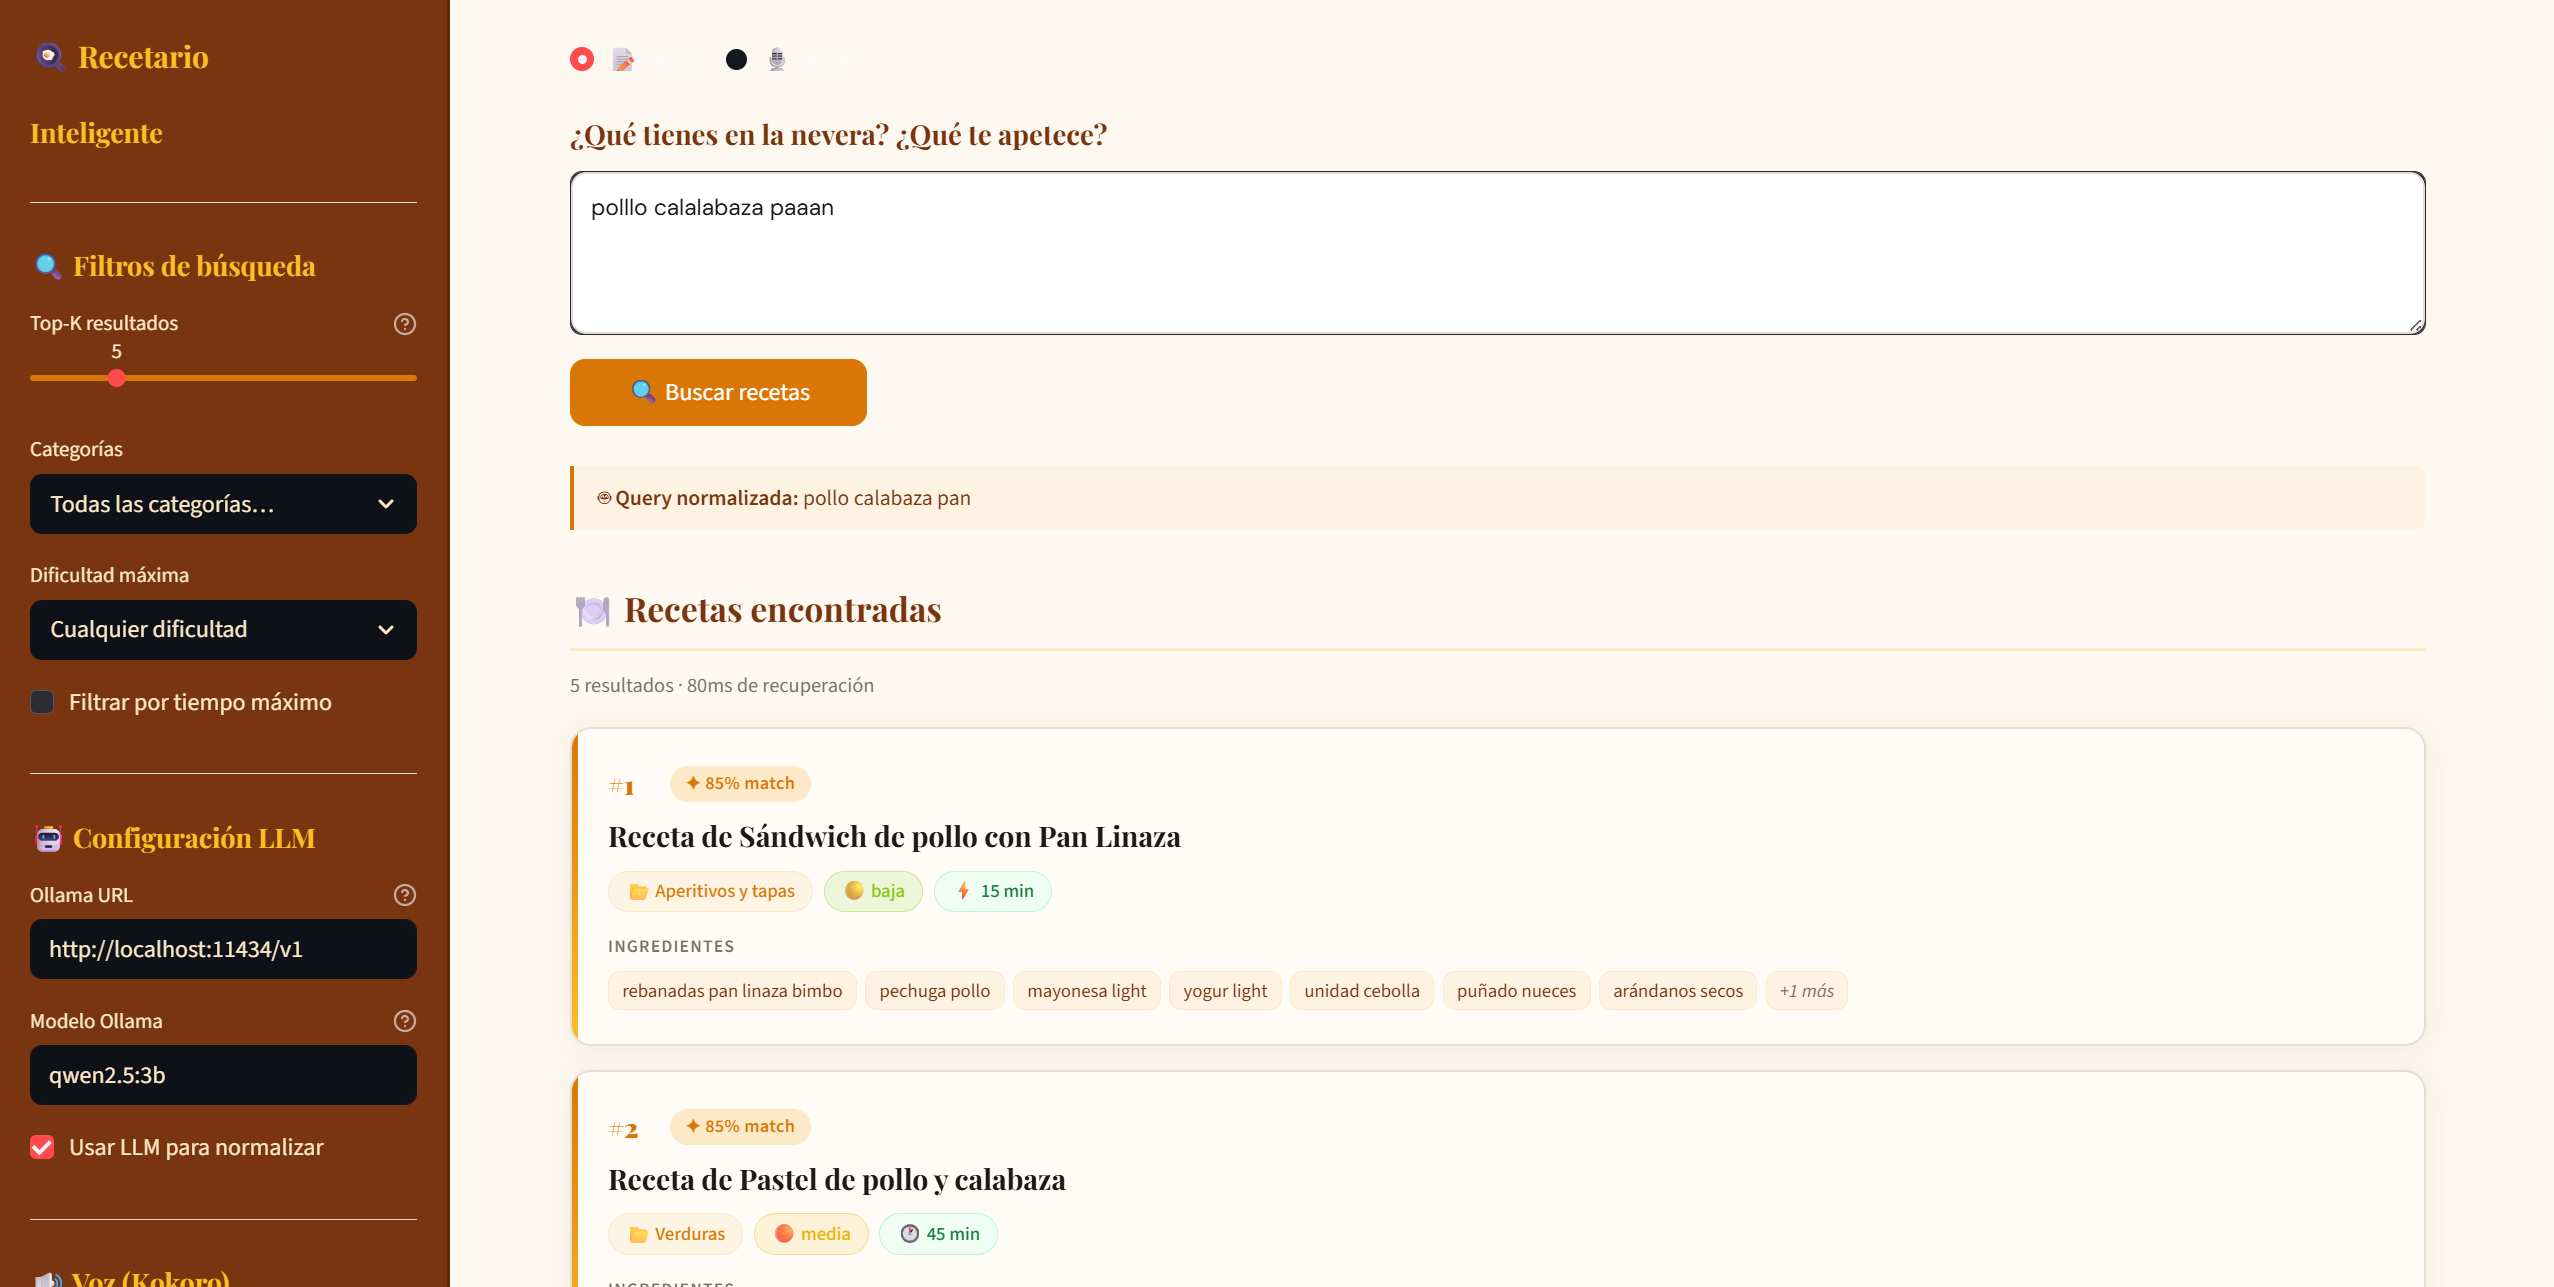

 Nota para exportación a html: Para pasar a html ejecutar esto: jupyter nbconvert --to html nlp.ipynb --template lab --embed-images --ClearMetadataPreprocessor.enabled=True
 Porque como en la carga de diferentes modelos hay widgets y logs y cosas raras da error si usamos el boton de exportación de vscode.